**Clone Github repo and set working directory path**

In [2]:
!git clone https://github.com/jamal94sm/TIHM.git
%cd /content/TIHM

Cloning into 'TIHM'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 105 (delta 39), reused 12 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 23.96 MiB | 4.39 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/content/TIHM


In [ ]:
#!rm -r TIHM

rm: cannot remove 'TIHM-Dataset-Visualization': No such file or directory


**Load packages**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import cm
import matplotlib.patches as mpatches
from collections.abc import Iterable
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from matplotlib import cm
#from utils import *

%matplotlib inline
## Set colour palette
ibm_colorblind = ['#648FFF', '#FE6100', '#DC267F', '#785EF0', '#FFB000','#48A9A6']
sns.set_palette(ibm_colorblind)

**Functions**

In [4]:
def correct_col_type(df,col):
    raw_type = str(type(df[col].dtype)).split('.')[-1].split('\'')[0].lower()
    #print(col,raw_type)
    if 'object' in raw_type:
        if 'date' in col or 'timestamp' in col or 'datetime' in col:
            return pd.to_datetime(df[col])
        else:
            return df[col].astype('category')
    else:
        return df[col]


def gen_date_col(df, tcol):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df[tcol].dt.date
    return df

**Set Data and Fig folders paths**

In [5]:
## Please change the path with the path of your dataset
DPATH = './Dataset'
SAVE_PATH = './Figs/'
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)



**Import Files**

In [6]:
### Labels
f = 'Labels.csv'
fpth = os.path.join(DPATH,f)
labels_df = pd.read_csv(fpth)
for col in labels_df.columns:
    labels_df[col] = correct_col_type(labels_df,col)
if 'date' in labels_df.columns:
    labels_df = labels_df.rename(columns={'date':'timestamp'})
if 'type' in labels_df.columns:
    labels_df = labels_df.rename(columns={'type':'label'})
labels_df = gen_date_col(labels_df,tcol='timestamp')

labels_patients = np.unique(labels_df['patient_id'])


In [7]:
### Activity

f = 'Activity.csv'
fpth = os.path.join(DPATH,f)
df = pd.read_csv(fpth)
for col in df.columns:
    df[col] = correct_col_type(df,col)
if 'date' in df.columns:
    activity_df = df.rename(columns={'date':'timestamp'})
    activity_df['timestamp'] = pd.to_datetime(activity_df['timestamp'])
    activity_df['date'] = activity_df['timestamp'].dt.date
    activity_df['time'] = activity_df['timestamp'].dt.time


activity_patients = np.unique(activity_df['patient_id'])

activity_df

,patient_id,location_name,timestamp,date,time
0,0697d,Fridge Door,2019-06-28 13:03:29,2019-06-28,13:03:29
1,0697d,Kitchen,2019-06-28 13:11:44,2019-06-28,13:11:44
2,0697d,Front Door,2019-06-28 13:13:50,2019-06-28,13:13:50
3,0697d,Bedroom,2019-06-28 13:13:53,2019-06-28,13:13:53
4,0697d,Fridge Door,2019-06-28 13:14:09,2019-06-28,13:14:09
...,...,...,...,...,...
1030554,fd100,Hallway,2019-06-30 23:48:50,2019-06-30,23:48:50
1030555,fd100,Lounge,2019-06-30 23:49:40,2019-06-30,23:49:40
1030556,fd100,Kitchen,2019-06-30 23:50:02,2019-06-30,23:50:02
1030557,fd100,Front Door,2019-06-30 23:51:28,2019-06-30,23:51:28


In [8]:
### patient id
id = '16f4b' # 11 agitation days, and 89 record day (78 normal days vs 11 agitation days)
id_activity_df = activity_df[activity_df['patient_id']==id]

# Patient Activity Types
id_activity_types = np.unique(id_activity_df['location_name'])

# Create a new column to identify if the patient is outside
id_activity_df['outside'] = id_activity_df['location_name'].isin(['Front Door', 'Back Door'])

# Initialize a list to store results
daily_time_outside = []

# Group by date
grouped = id_activity_df.groupby(id_activity_df['timestamp'].dt.date)

for date, group in grouped:
    total_time_outside = 0

    # Iterate through the group to calculate time spent outside (in minutes)
    for i in range(1, len(group)):
        if group['outside'].iloc[i] and group['outside'].iloc[i - 1]:
            time_diff = (group['timestamp'].iloc[i] - group['timestamp'].iloc[i - 1]).total_seconds() / 60
            total_time_outside += time_diff

    daily_time_outside.append({'date': date, 'time_spent_outside': total_time_outside})

# Convert results to DataFrame
results_df = pd.DataFrame(daily_time_outside)

# Print the results
print(id_activity_df)

       patient_id location_name           timestamp        date      time  \
80264       16f4b       Hallway 2019-04-01 00:05:46  2019-04-01  00:05:46   
80265       16f4b       Hallway 2019-04-01 04:55:16  2019-04-01  04:55:16   
80266       16f4b       Bedroom 2019-04-01 05:10:33  2019-04-01  05:10:33   
80267       16f4b       Kitchen 2019-04-01 10:15:09  2019-04-01  10:15:09   
80268       16f4b      Bathroom 2019-04-01 10:15:53  2019-04-01  10:15:53   
...           ...           ...                 ...         ...       ...   
113325      16f4b       Kitchen 2019-06-30 23:27:28  2019-06-30  23:27:28   
113326      16f4b      Bathroom 2019-06-30 23:27:41  2019-06-30  23:27:41   
113327      16f4b      Bathroom 2019-06-30 23:45:26  2019-06-30  23:45:26   
113328      16f4b      Bathroom 2019-06-30 23:46:39  2019-06-30  23:46:39   
113329      16f4b       Hallway 2019-06-30 23:47:22  2019-06-30  23:47:22   

        outside  
80264     False  
80265     False  
80266     False  
802

In [31]:
# Example patient ID and activity data (for demonstration purposes)
id = '16f4b'  # Replace with the actual patient ID
# activity_df and agitation_df should be defined or loaded with your data here

# Filter activity data for the specific patient
id_activity_df = activity_df[activity_df['patient_id'] == id]

# Activity days, normal_days, and agitation_days
activity_days = activity_df['date'][activity_df['patient_id'] == id].unique()
agitation_df = labels_df[labels_df['label']=='Agitation'].copy()
agitation_days = agitation_df['date'][agitation_df['patient_id'] == id].unique()
normal_days = activity_days[~np.isin(activity_days, agitation_days)]

# Step 1: Calculate mobility changes
mobility_data = id_activity_df.groupby('date')['location_name'].apply(lambda x: x.values)

# Calculate mobility changes
mobility_counts = mobility_data.apply(lambda each_day_activity_sequence: np.nansum(np.concatenate([[np.NaN], each_day_activity_sequence[1:] != each_day_activity_sequence[:-1]])))

# Create mobility_df with mobility counts
mobility_df = pd.DataFrame({
    'date': mobility_counts.index,
    'mobility': mobility_counts.values
})

# Add a new column to mobility_df to specify normal and agitation days
mobility_df['day_type'] = mobility_df['date'].apply(lambda x: 'agitation' if x in agitation_days else 'normal')

# Calculate time spent outside each day
id_activity_df['outside'] = id_activity_df['location_name'].isin(['Front Door', 'Back Door'])

# Initialize list for daily outside time calculations
daily_time_outside = []

# Group by date
grouped = id_activity_df.groupby(id_activity_df['timestamp'].dt.date)

for date, group in grouped:
    total_time_outside = 0

    # Iterate through the group to calculate time spent outside
    for i in range(1, len(group)):
        if group['outside'].iloc[i] and group['outside'].iloc[i - 1]:
            time_diff = (group['timestamp'].iloc[i] - group['timestamp'].iloc[i - 1]).total_seconds() / 60
            total_time_outside += time_diff

    daily_time_outside.append({'date': date, 'time_spent_outside': total_time_outside})

# Convert daily_time_outside to DataFrame
time_outside_df = pd.DataFrame(daily_time_outside)

# Merge time spent outside into mobility_df
mobility_df = mobility_df.merge(time_outside_df, on='date', how='left')

# Optionally, include patient_id if needed
mobility_df['patient_id'] = id  # Add the patient_id

# Save the output to a CSV file
mobility_df.to_csv('mobility_data_with_time_outside.csv', index=False)

# Display the new DataFrame
print(mobility_df)
print(mobility_df[mobility_df['day_type'] == 'agitation'])

          date  mobility day_type  time_spent_outside patient_id
0   2019-04-01      28.0   normal            0.000000      16f4b
1   2019-04-03      94.0   normal            0.000000      16f4b
2   2019-04-04     308.0   normal            5.400000      16f4b
3   2019-04-05     384.0   normal            4.266667      16f4b
4   2019-04-06     305.0   normal            4.783333      16f4b
..         ...       ...      ...                 ...        ...
84  2019-06-26     135.0   normal            7.716667      16f4b
85  2019-06-27     185.0   normal           15.916667      16f4b
86  2019-06-28     194.0   normal           10.250000      16f4b
87  2019-06-29     128.0   normal          132.733333      16f4b
88  2019-06-30     151.0   normal            2.300000      16f4b

[89 rows x 5 columns]
          date  mobility   day_type  time_spent_outside patient_id
9   2019-04-11     356.0  agitation            2.483333      16f4b
12  2019-04-14     420.0  agitation            2.400000      16

# Nutrition

In [30]:
### patient id
id = '099bc'
id_activity_df = activity_df[activity_df['patient_id']==id]

#print(id_activity_df[:50])


# Convert timestamp to datetime if not already done
id_activity_df['timestamp'] = pd.to_datetime(id_activity_df['timestamp'])

# Create a new column to identify changes in location
id_activity_df['prev_location'] = id_activity_df['location_name'].shift(1)

# Create a column to mark when we have a "Fridge Door" entry that is not preceded by another "Fridge Door"
id_activity_df['is_fridge_visit'] = ((id_activity_df['location_name'] == 'Fridge Door') &
                                      (id_activity_df['prev_location'] != 'Fridge Door'))

# Create a new DataFrame that counts unique visits of 'Fridge Door' per patient per day
fridge_counts = (id_activity_df.groupby(['patient_id', 'date'])
                 .agg(fridge_door_count=('is_fridge_visit', 'sum'))
                 .reset_index())

# Merge the counts back into the original DataFrame
id_activity_df = id_activity_df.merge(fridge_counts, on=['patient_id', 'date'], how='left')

# Fill NaN values with 0 (in case there were no visits to the Fridge Door)
id_activity_df['fridge_door_count'].fillna(0, inplace=True)

# Convert the count to integer type
id_activity_df['fridge_door_count'] = id_activity_df['fridge_door_count'].astype(int)

# Drop the auxiliary columns if not needed
id_activity_df.drop(columns=['prev_location', 'is_fridge_visit'], inplace=True)

# Display the updated DataFrame
print(id_activity_df)

      patient_id location_name           timestamp        date      time  \
0          099bc       Kitchen 2019-05-15 12:19:32  2019-05-15  12:19:32   
1          099bc    Front Door 2019-05-15 12:20:20  2019-05-15  12:20:20   
2          099bc   Fridge Door 2019-05-15 12:20:21  2019-05-15  12:20:21   
3          099bc     Back Door 2019-05-15 12:20:24  2019-05-15  12:20:24   
4          099bc       Kitchen 2019-05-15 12:23:22  2019-05-15  12:23:22   
...          ...           ...                 ...         ...       ...   
11933      099bc       Bedroom 2019-06-30 22:47:31  2019-06-30  22:47:31   
11934      099bc       Bedroom 2019-06-30 23:24:04  2019-06-30  23:24:04   
11935      099bc      Bathroom 2019-06-30 23:24:25  2019-06-30  23:24:25   
11936      099bc      Bathroom 2019-06-30 23:26:43  2019-06-30  23:26:43   
11937      099bc       Bedroom 2019-06-30 23:26:56  2019-06-30  23:26:56   

       fridge_door_count  
0                     12  
1                     12  
2     

## Physiology Data Repairing

In [9]:
### Physiology
f = 'Physiology.csv'
fpth = os.path.join(DPATH,f)
df = pd.read_csv(fpth)
for col in df.columns:
    df[col] = correct_col_type(df,col)
if 'date' in df.columns:
    physiology_df = df.rename(columns={'date':'timestamp'})
physiology_df = gen_date_col(physiology_df,tcol='timestamp')

physiology_patients = np.unique(df['patient_id'])
physiology_parameters = np.unique(df['device_type']).tolist()

physiology_df[:50]

,patient_id,timestamp,device_type,value,unit,date
0,0697d,2019-06-28 13:42:09,Body Temperature,36.072,Cel,2019-06-28
1,0697d,2019-06-28 13:42:44,Body Temperature,35.831,Cel,2019-06-28
2,0697d,2019-06-28 13:43:40,Body Temperature,35.831,Cel,2019-06-28
3,0697d,2019-06-28 13:45:15,Systolic blood pressure,165.000,mm[Hg],2019-06-28
4,0697d,2019-06-28 13:45:15,Diastolic blood pressure,82.000,mm[Hg],2019-06-28
5,0697d,2019-06-28 13:45:15,Heart rate,42.000,beats/min,2019-06-28
6,0697d,2019-06-28 14:25:07,Body Temperature,36.599,Cel,2019-06-28
7,0697d,2019-06-28 14:25:37,Body Temperature,36.599,Cel,2019-06-28
8,0697d,2019-06-28 14:40:13,Body weight,86.300,kg,2019-06-28
9,0697d,2019-06-28 14:40:13,O/E - muscle mass,64.500,kg,2019-06-28


In [10]:
# Get the unique patient IDs and device types
patients = physiology_df['patient_id'].unique()
device_types = physiology_df['device_type'].unique()

# Create a DataFrame that retains original study days for each patient
study_days = physiology_df[['patient_id', 'date']].drop_duplicates()

# Prepare a list to hold the filled results
filled_results_list = []

# Iterate over each patient
for patient in patients:
    # Get the patient's data
    patient_data = physiology_df[physiology_df['patient_id'] == patient]

    # For each study day, check measurements
    for date in study_days[study_days['patient_id'] == patient]['date']:
        for device in device_types:
            # Get all values for this patient, date, and device type
            values = patient_data.loc[(patient_data['date'] == date) & (patient_data['device_type'] == device), 'value']
            if not values.empty:
                # Compute the average value (considering repetitions)
                avg_value = values.mean()
                unit = patient_data.loc[(patient_data['date'] == date) & (patient_data['device_type'] == device), 'unit'].values[0]
                filled_results_list.append({
                    'patient_id': patient,
                    'date': date,
                    'device_type': device,
                    'value': avg_value,
                    'unit': unit
                })
            else:
                # If there are no measurements, append a None
                filled_results_list.append({
                    'patient_id': patient,
                    'date': date,
                    'device_type': device,
                    'value': None,  # To be filled later
                    'unit': None
                })

# Convert the list of dictionaries to a DataFrame
filled_results = pd.DataFrame(filled_results_list)

# Now, we can fill in the missing values
def fill_missing_values(group):
    for device in device_types:
        # Patient's specific values for this device
        patient_values = group[group['device_type'] == device]['value']

        # If any values exist, calculate the average to fill
        if patient_values.notnull().any():
            avg_patient_value = patient_values.mean()
            group.loc[(group['device_type'] == device) & (group['value'].isnull()), 'value'] = avg_patient_value
        else:
            # If no values exist at all, use the overall average for this device if applicable
            if physiology_df[physiology_df['device_type'] == device]['value'].notna().any():
                overall_avg = physiology_df[physiology_df['device_type'] == device]['value'].mean()
                group.loc[(group['device_type'] == device) & (group['value'].isnull()), 'value'] = overall_avg

    return group

# Apply filling logic to the filled_results DataFrame
filled_physiology_df = filled_results.groupby('patient_id', group_keys=False).apply(fill_missing_values)

# Sort by patient_id and date
filled_physiology_df.sort_values(by=['patient_id', 'date'], inplace=True)


In [20]:
id = '099bc'

'''
average parameters for healthy adults over 70
Diastolic Blood Pressure: 75 mmHg
Body Temperature: 97°F (36.1°C)
Skin Temperature: 93°F (34°C)
'''
avg_DBP = 75
avg_BT = 36.1
std_DBP = 10
std_BT = 0.5

id_physiology_df = filled_physiology_df[filled_physiology_df['patient_id']==id]
print(id_physiology_df)
# Create a new DataFrame for z-scores
health_df = pd.DataFrame()

# Calculate z-score for Diastolic Blood Pressure
dbp_data = id_physiology_df[id_physiology_df['device_type'] == 'Diastolic blood pressure']
health_df['date'] = dbp_data['date']
health_df['z_score_DBP'] = (dbp_data['value'] - avg_DBP) / std_DBP

# Calculate z-score for Body Temperature
bt_data = id_physiology_df[id_physiology_df['device_type'] == 'Body Temperature']
health_df = health_df.merge(bt_data[['date', 'value']], on='date', how='left', suffixes=('', '_BT'))
health_df['z_score_BT'] = (health_df['value'] - avg_BT) / std_BT

# Optionally, remove the original value columns if not needed
health_df.drop(columns=['value'], inplace=True)

# Display the resulting DataFrame with z-scores
print(health_df)

    patient_id        date               device_type       value       unit
24       099bc  2019-05-15          Body Temperature   37.229286        Cel
25       099bc  2019-05-15   Systolic blood pressure  127.000000     mm[Hg]
26       099bc  2019-05-15  Diastolic blood pressure   75.500000     mm[Hg]
27       099bc  2019-05-15                Heart rate   82.500000  beats/min
28       099bc  2019-05-15               Body weight   53.300000         kg
..         ...         ...                       ...         ...        ...
355      099bc  2019-06-30                Heart rate   76.500000  beats/min
356      099bc  2019-06-30               Body weight   51.900000         kg
357      099bc  2019-06-30         O/E - muscle mass   36.700000         kg
358      099bc  2019-06-30          Total body water   51.400000          %
359      099bc  2019-06-30          Skin Temperature   34.151209       None

[336 rows x 5 columns]
          date  z_score_DBP  z_score_BT
0   2019-05-15     0.050

# **Static Analysis**

**Z-score Analysis based on mobility**

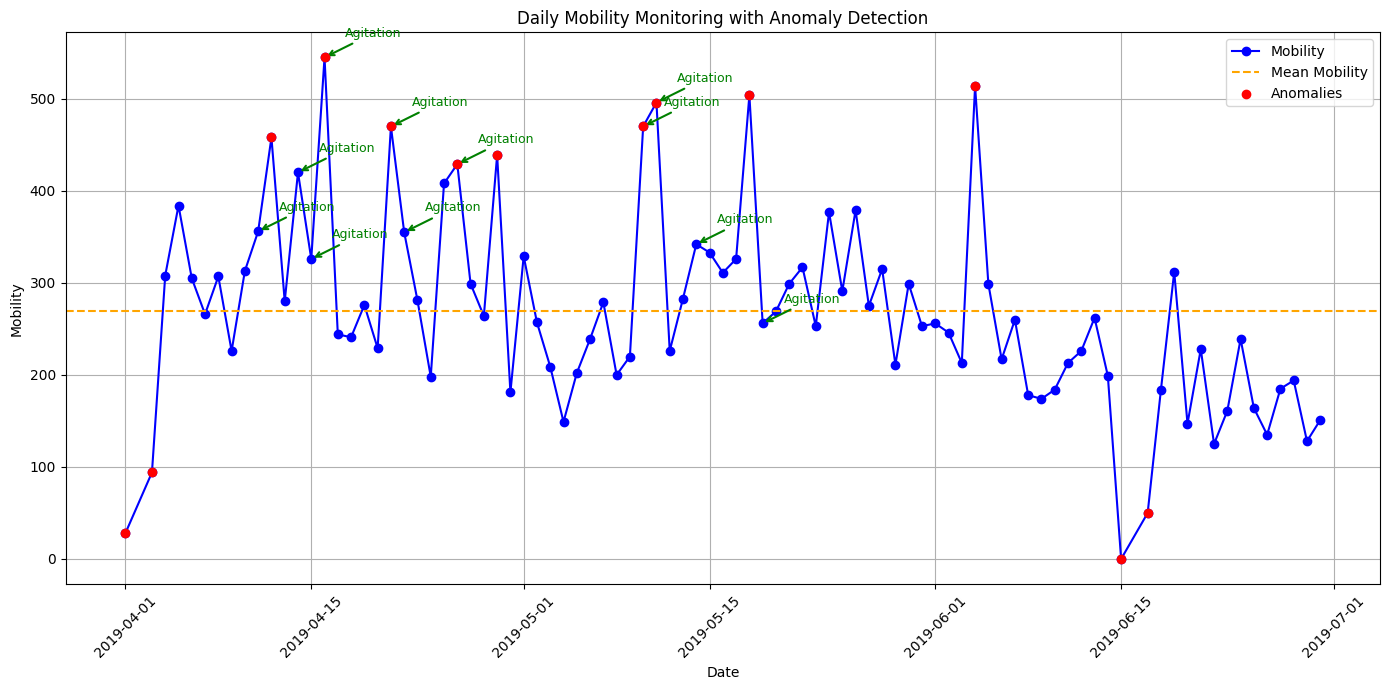

          date  mobility day_type  time_spent_outside patient_id   z_score  \
0   2019-04-01      28.0   normal            0.000000      16f4b -2.292828   
1   2019-04-03      94.0   normal            0.000000      16f4b -1.664975   
2   2019-04-04     308.0   normal            5.400000      16f4b  0.370790   
3   2019-04-05     384.0   normal            4.266667      16f4b  1.093772   
4   2019-04-06     305.0   normal            4.783333      16f4b  0.342251   
..         ...       ...      ...                 ...        ...       ...   
84  2019-06-26     135.0   normal            7.716667      16f4b -1.274946   
85  2019-06-27     185.0   normal           15.916667      16f4b -0.799299   
86  2019-06-28     194.0   normal           10.250000      16f4b -0.713683   
87  2019-06-29     128.0   normal          132.733333      16f4b -1.341536   
88  2019-06-30     151.0   normal            2.300000      16f4b -1.122739   

    anomaly  
0      True  
1      True  
2     False  
3     F

In [12]:
import matplotlib.pyplot as plt
from scipy import stats

# Calculate the Z-score for mobility
mobility_df['z_score'] = stats.zscore(mobility_df['mobility'])

# Define a threshold to identify anomalies
threshold = 1.5

# Identify anomalies based on Z-score
mobility_df['anomaly'] = mobility_df['z_score'].abs() > threshold

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['mobility'], marker='o', label='Mobility', color='blue')
plt.axhline(y=mobility_df['mobility'].mean(), color='orange', linestyle='--', label='Mean Mobility')
plt.scatter(mobility_df['date'][mobility_df['anomaly']],
            mobility_df['mobility'][mobility_df['anomaly']],
            color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Daily Mobility Monitoring with Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Annotate agitation days if needed
for date in agitation_days:
    mobility_value = mobility_df[mobility_df['date'] == date]['mobility'].values[0]  # Get the mobility value for the agitation date
    plt.annotate('Agitation',
                 xy=(date, mobility_value),
                 xytext=(15, 15),  # Offset the text position
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9,
                 color='green')

plt.tight_layout()

# Show the plot
plt.show()

# Display the mobility_df with Z-scores and anomalies
print(mobility_df)

**Z-score based on ouside time**

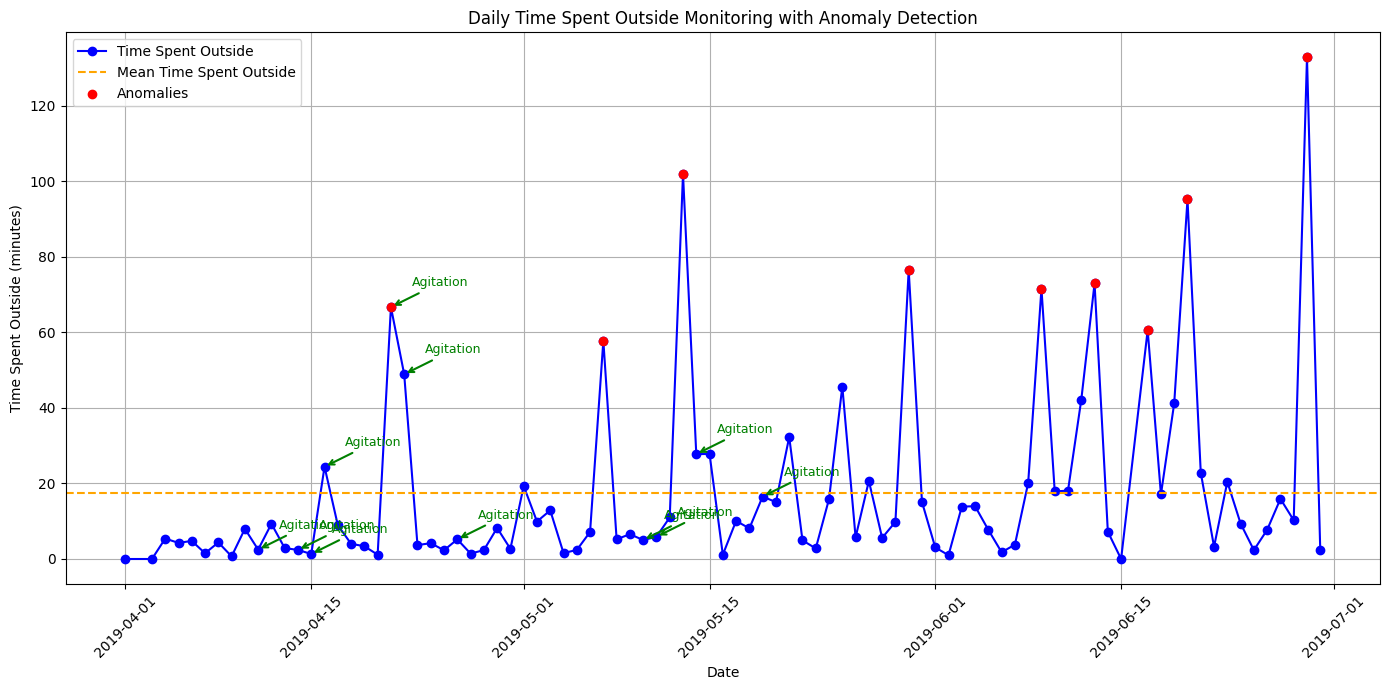

In [13]:
# Calculate the Z-score for time spent outside
mobility_df['z_score_outside'] = stats.zscore(mobility_df['time_spent_outside'])  # Fill NaNs if necessary

# Define a threshold to identify anomalies in time spent outside
threshold = 1.5

# Identify anomalies based on Z-score
mobility_df['anomaly_outside'] = mobility_df['z_score_outside'].abs() > threshold

# Plotting time spent outside
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['time_spent_outside'], marker='o', label='Time Spent Outside', color='blue')
plt.axhline(y=mobility_df['time_spent_outside'].mean(), color='orange', linestyle='--', label='Mean Time Spent Outside')
plt.scatter(mobility_df['date'][mobility_df['anomaly_outside']],
            mobility_df['time_spent_outside'][mobility_df['anomaly_outside']],
            color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Daily Time Spent Outside Monitoring with Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Time Spent Outside (minutes)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Optionally, annotate agitation days on the time spent outside plot
for date in agitation_days:
    outside_value = mobility_df[mobility_df['date'] == date]['time_spent_outside'].values[0]  # Get the outside time for the agitation date
    plt.annotate('Agitation',
                 xy=(date, outside_value),
                 xytext=(15, 15),  # Offset the text position
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9,
                 color='green')

plt.tight_layout()

# Show the plot
plt.show()

**Z-score based on mobility and ouside time**

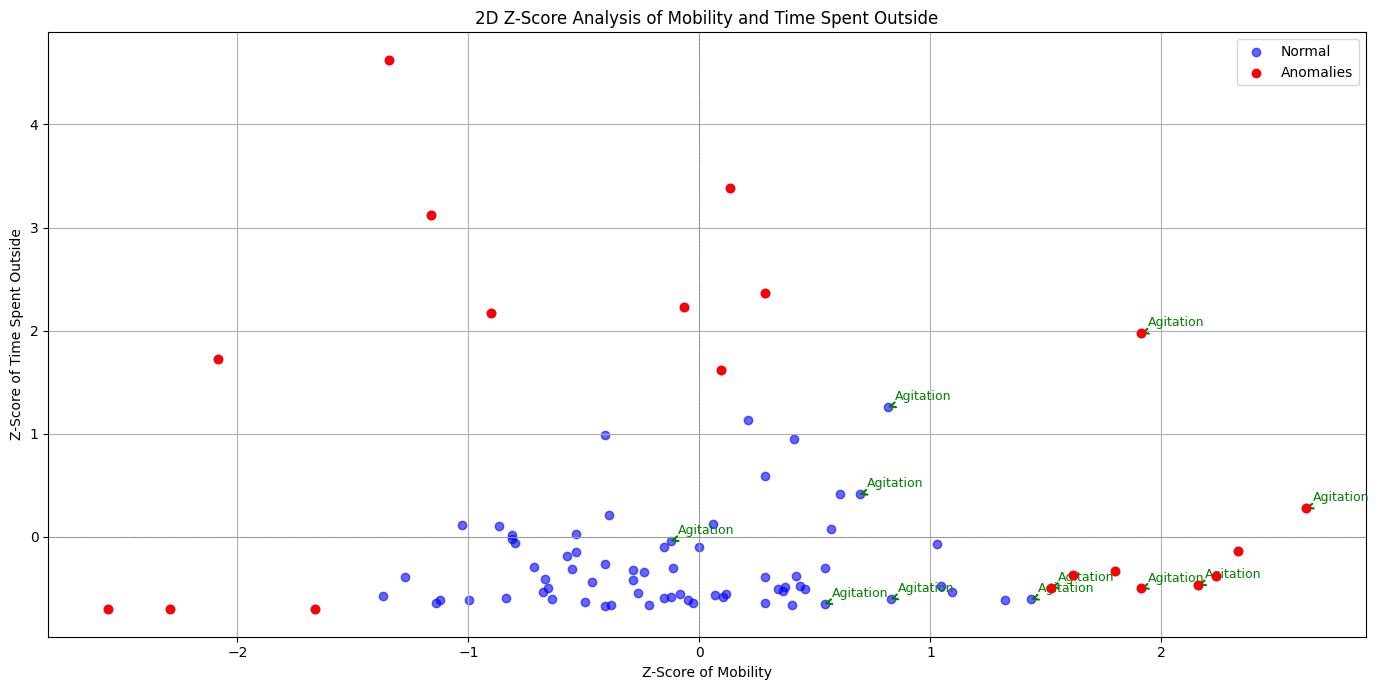

          date  mobility  time_spent_outside  z_score_mobility  \
0   2019-04-01      28.0            0.000000         -2.292828   
1   2019-04-03      94.0            0.000000         -1.664975   
2   2019-04-04     308.0            5.400000          0.370790   
3   2019-04-05     384.0            4.266667          1.093772   
4   2019-04-06     305.0            4.783333          0.342251   
..         ...       ...                 ...               ...   
84  2019-06-26     135.0            7.716667         -1.274946   
85  2019-06-27     185.0           15.916667         -0.799299   
86  2019-06-28     194.0           10.250000         -0.713683   
87  2019-06-29     128.0          132.733333         -1.341536   
88  2019-06-30     151.0            2.300000         -1.122739   

    z_score_outside  anomaly_mobility  anomaly_outside  
0         -0.703600              True            False  
1         -0.703600              True            False  
2         -0.486716             Fals

In [14]:
# Calculate the Z-scores for both mobility and time spent outside
mobility_df['z_score_mobility'] = stats.zscore(mobility_df['mobility'])  # Fill NaNs if necessary
mobility_df['z_score_outside'] = stats.zscore(mobility_df['time_spent_outside'])  # Fill NaNs if necessary

# Define a threshold to identify anomalies for both features
threshold = 1.5

# Identify anomalies based on Z-scores
mobility_df['anomaly_mobility'] = mobility_df['z_score_mobility'].abs() > threshold
mobility_df['anomaly_outside'] = mobility_df['z_score_outside'].abs() > threshold

# Plotting the 2D Z-score analysis
plt.figure(figsize=(14, 7))
plt.scatter(mobility_df['z_score_mobility'], mobility_df['z_score_outside'],
            c='blue', label='Normal', alpha=0.6)

# Highlight anomalies
plt.scatter(mobility_df['z_score_mobility'][mobility_df['anomaly_mobility'] | mobility_df['anomaly_outside']],
            mobility_df['z_score_outside'][mobility_df['anomaly_mobility'] | mobility_df['anomaly_outside']],
            color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('2D Z-Score Analysis of Mobility and Time Spent Outside')
plt.xlabel('Z-Score of Mobility')
plt.ylabel('Z-Score of Time Spent Outside')
plt.axhline(0, color='grey', lw=0.5, linestyle='--')
plt.axvline(0, color='grey', lw=0.5, linestyle='--')
plt.legend()
plt.grid()

# Annotate agitation days
for index, row in mobility_df[mobility_df['day_type'] == 'agitation'].iterrows():
    plt.annotate('Agitation',
                 xy=(row['z_score_mobility'], row['z_score_outside']),
                 xytext=(5, 5),  # Offset the text position
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9,
                 color='green')

plt.tight_layout()

# Show the plot
plt.show()

# Display the mobility_df with Z-scores and anomalies
print(mobility_df[['date', 'mobility', 'time_spent_outside', 'z_score_mobility', 'z_score_outside', 'anomaly_mobility', 'anomaly_outside']])


**K-means based on mobility**

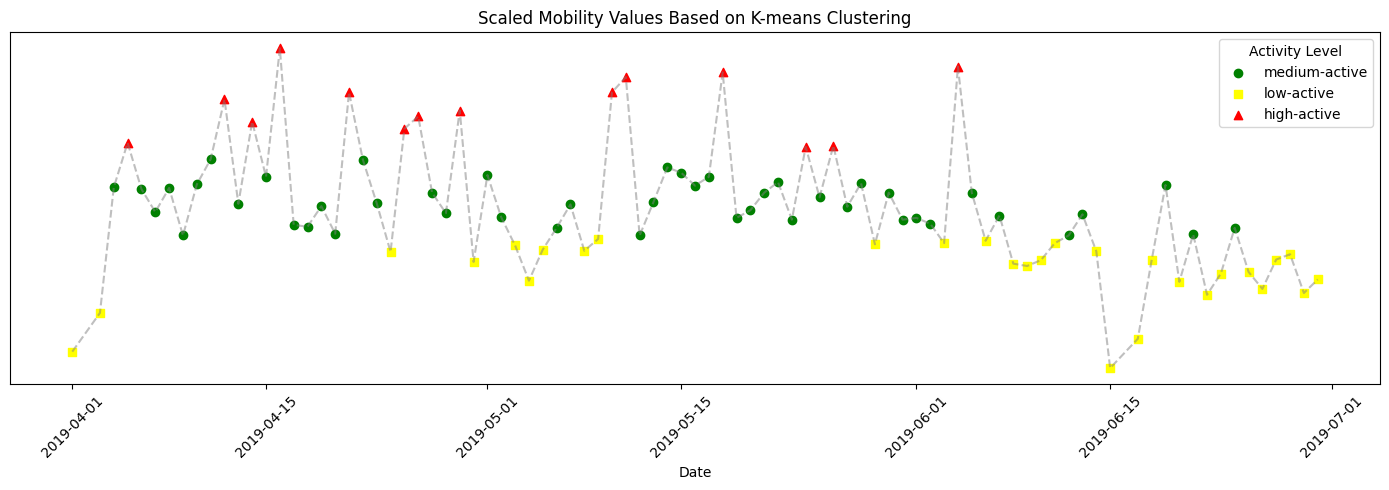

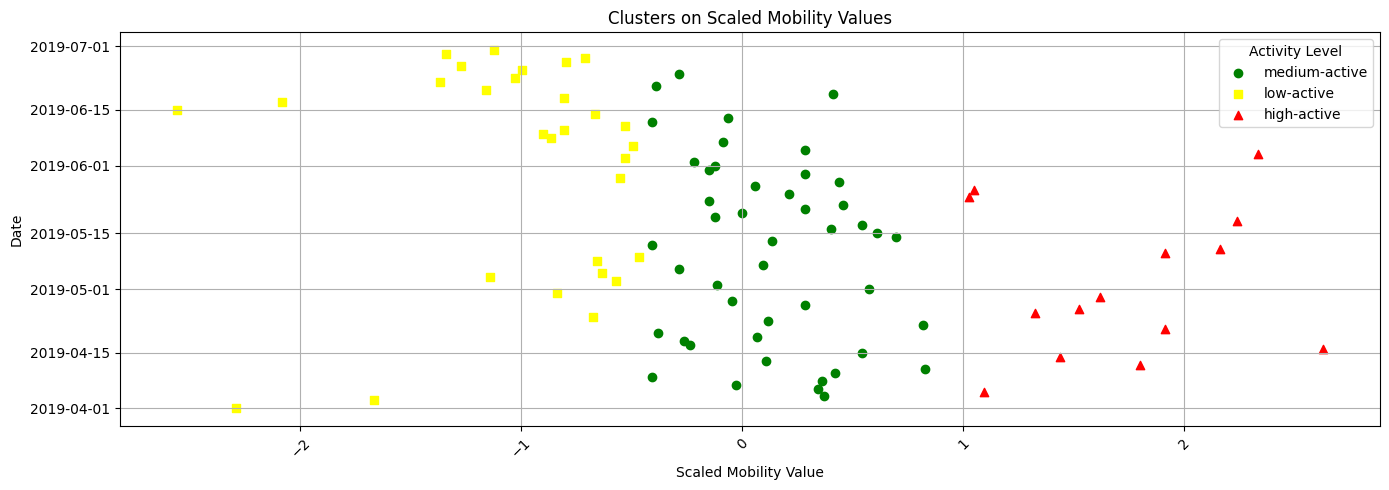

          date  mobility activity_level
0   2019-04-01      28.0     low-active
1   2019-04-03      94.0     low-active
2   2019-04-04     308.0  medium-active
3   2019-04-05     384.0    high-active
4   2019-04-06     305.0  medium-active
..         ...       ...            ...
84  2019-06-26     135.0     low-active
85  2019-06-27     185.0     low-active
86  2019-06-28     194.0     low-active
87  2019-06-29     128.0     low-active
88  2019-06-30     151.0     low-active

[89 rows x 3 columns]


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize the mobility data
scaler = StandardScaler()
mobility_scaled = scaler.fit_transform(mobility_df[['mobility']])

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
mobility_df['cluster'] = kmeans.fit_predict(mobility_scaled)

# Map cluster numbers to activity labels (change the labels as requested)
activity_labels = ['medium-active', 'low-active', 'high-active']  # Adjusted so the lowest value is medium-active
mobility_df['activity_level'] = mobility_df['cluster'].map(lambda x: activity_labels[x])

# Adding activity_type column for clarity
mobility_df['activity_type'] = mobility_df['activity_level']

# Plotting clusters on a 1-D axis with different colors
plt.figure(figsize=(14, 5))
colors = ['green', 'yellow', 'red']  # Define colors for each activity level
markers = ['o', 's', '^']  # Different markers for better differentiation

# Create a scatter plot for the scaled mobility values
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_df['date'][mobility_df['activity_level'] == label],
                mobility_scaled[mobility_df['activity_level'] == label],  # Using scaled mobility values
                color=colors[i], label=label, marker=markers[i])

# Adding dashed lines to connect the points
plt.plot(mobility_df['date'], mobility_scaled, linestyle='--', color='gray', alpha=0.5)

# Customizing the plot for scaled mobility values
plt.yticks([])
plt.title('Scaled Mobility Values Based on K-means Clustering')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Activity Level')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()

# Create another figure for scaled mobility values with clusters
plt.figure(figsize=(14, 5))

# Create a scatter plot with scaled mobility values on the x-axis
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_scaled[mobility_df['activity_level'] == label],
                mobility_df['date'][mobility_df['activity_level'] == label],
                color=colors[i], label=label, marker=markers[i])

# Customizing the second plot
plt.title('Clusters on Scaled Mobility Values')
plt.xlabel('Scaled Mobility Value')
plt.ylabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Activity Level')
plt.grid(True)
plt.tight_layout()

# Show the second plot
plt.show()

# Display the mobility_df with clusters and activity levels
print(mobility_df[['date', 'mobility', 'activity_level']])


**K-means based on mobility and ouside time**

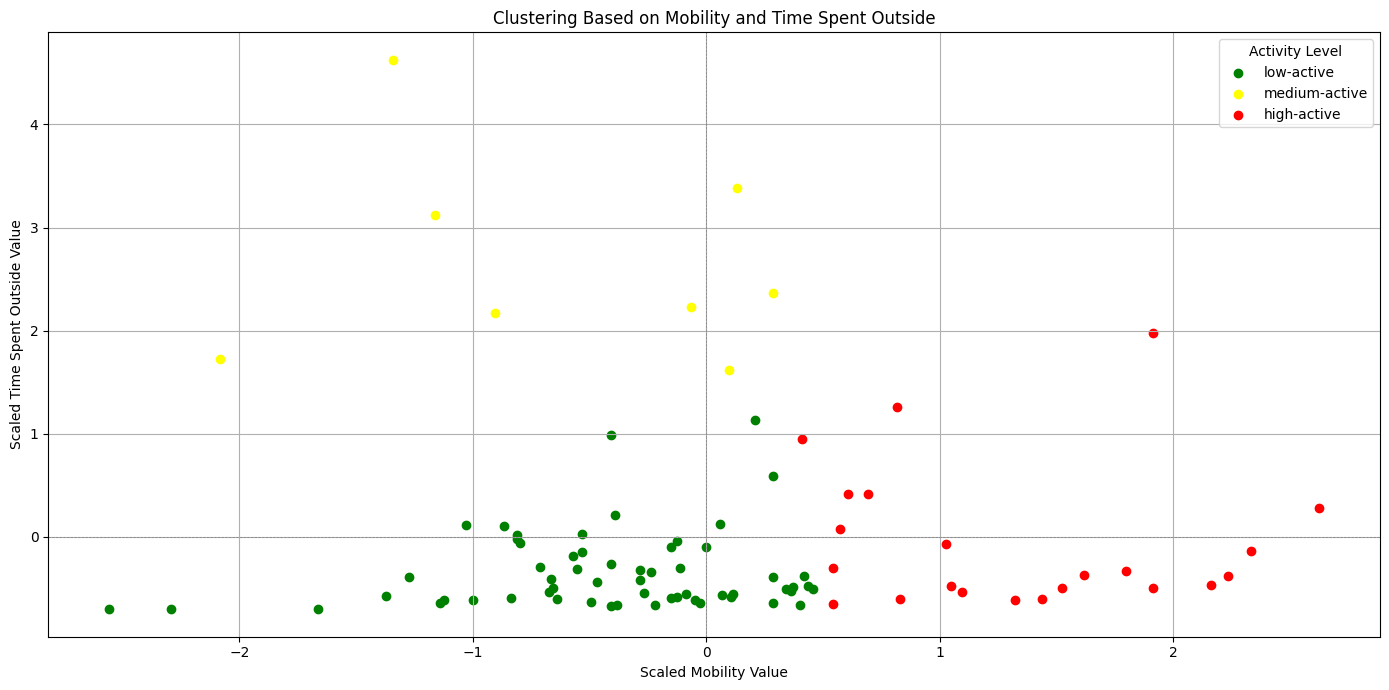

          date  mobility  time_spent_outside activity_level
0   2019-04-01      28.0            0.000000     low-active
1   2019-04-03      94.0            0.000000     low-active
2   2019-04-04     308.0            5.400000     low-active
3   2019-04-05     384.0            4.266667    high-active
4   2019-04-06     305.0            4.783333     low-active
..         ...       ...                 ...            ...
84  2019-06-26     135.0            7.716667     low-active
85  2019-06-27     185.0           15.916667     low-active
86  2019-06-28     194.0           10.250000     low-active
87  2019-06-29     128.0          132.733333  medium-active
88  2019-06-30     151.0            2.300000     low-active

[89 rows x 4 columns]


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize the mobility and time spent outside data
scaler = StandardScaler()
mobility_scaled = scaler.fit_transform(mobility_df[['mobility', 'time_spent_outside']])

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
mobility_df['cluster'] = kmeans.fit_predict(mobility_scaled)

# Map cluster numbers to activity labels
activity_labels = ['low-active', 'medium-active', 'high-active']  # Adjusted so the lowest value is medium-active
mobility_df['activity_level'] = mobility_df['cluster'].map(lambda x: activity_labels[x])

# Adding activity_type column for clarity
mobility_df['activity_type'] = mobility_df['activity_level']

# Plotting clusters on a 2D feature space
plt.figure(figsize=(14, 7))
colors = ['green', 'yellow', 'red']  # Define colors for each activity level

# Create a scatter plot for the scaled mobility and time spent outside values
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_scaled[mobility_df['activity_level'] == label, 0],  # Scaled mobility values
                mobility_scaled[mobility_df['activity_level'] == label, 1],  # Scaled time spent outside values
                color=colors[i], label=label)

# Customize the plot
plt.title('Clustering Based on Mobility and Time Spent Outside')
plt.xlabel('Scaled Mobility Value')
plt.ylabel('Scaled Time Spent Outside Value')
plt.axhline(0, color='grey', lw=0.5, linestyle='--')
plt.axvline(0, color='grey', lw=0.5, linestyle='--')
plt.legend(title='Activity Level')
plt.grid()
plt.tight_layout()

# Show the plot
plt.show()

# Display the mobility_df with clusters and activity levels
print(mobility_df[['date', 'mobility', 'time_spent_outside', 'activity_level']])

**Gaussian Mixture Model based on mobility**

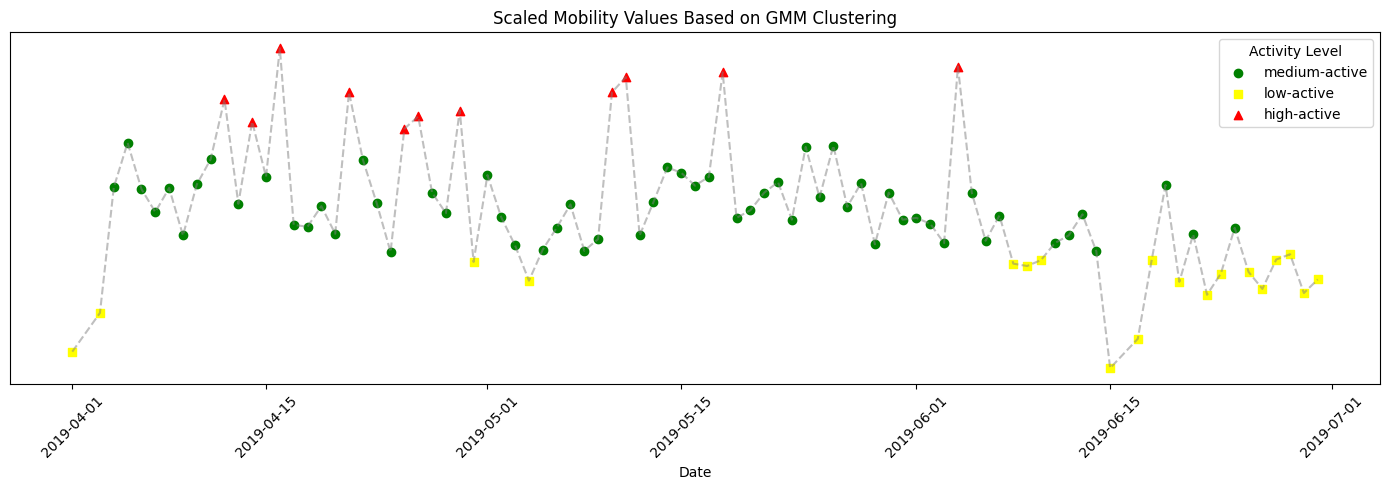

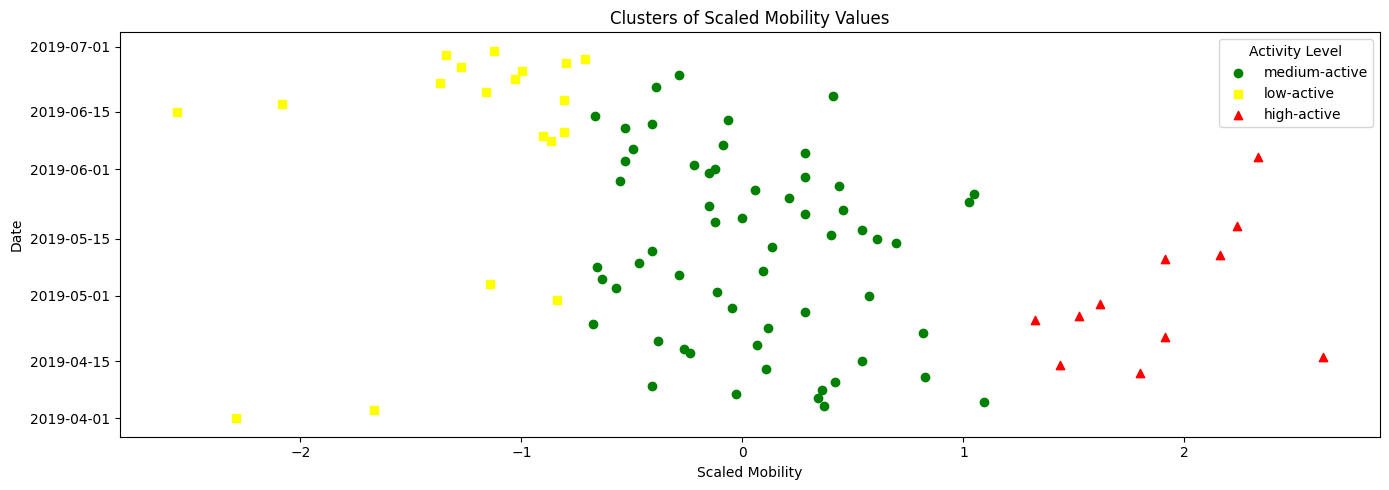

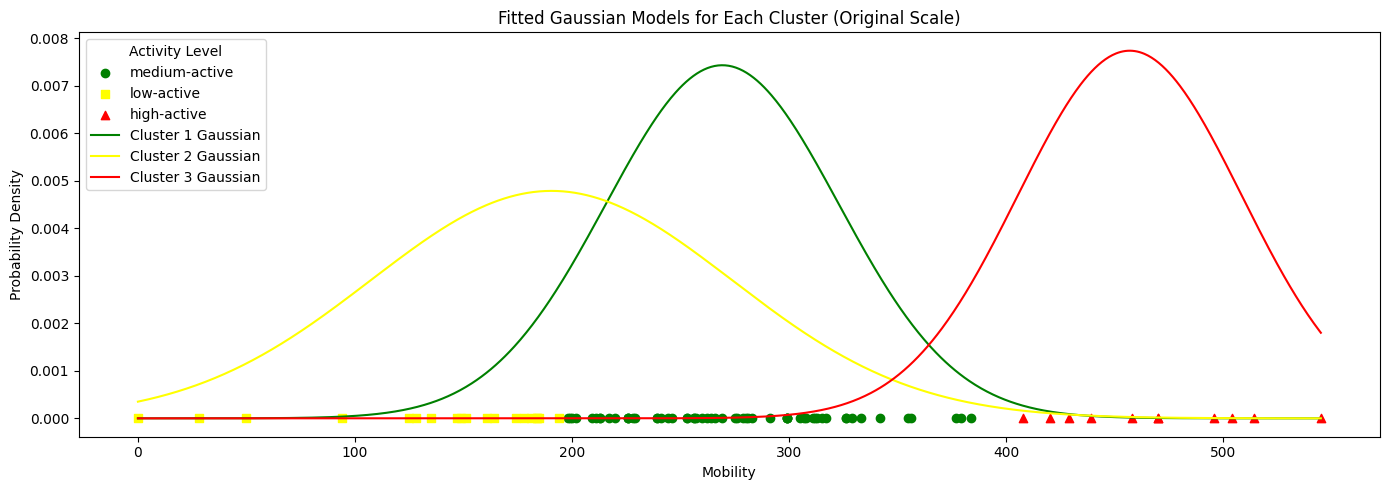

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import numpy as np

# Normalize the mobility data
scaler = StandardScaler()
mobility_scaled = scaler.fit_transform(mobility_df[['mobility']])

# Apply GMM clustering
gmm = GaussianMixture(n_components=3, random_state=0)
mobility_df['cluster'] = gmm.fit_predict(mobility_scaled)

# Map cluster numbers to activity labels (change the labels as requested)
activity_labels = ['medium-active', 'low-active', 'high-active']  # Adjusted so the lowest value is medium-active
mobility_df['activity_level'] = mobility_df['cluster'].map(lambda x: activity_labels[x])

# Adding activity_type column for clarity
mobility_df['activity_type'] = mobility_df['activity_level']

# Plotting clusters on a 1-D axis with different colors
plt.figure(figsize=(14, 5))
colors = ['green', 'yellow', 'red']  # Define colors for each activity level
markers = ['o', 's', '^']  # Different markers for better differentiation

# Create a scatter plot for the scaled mobility values
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_df['date'][mobility_df['activity_level'] == label],
                mobility_scaled[mobility_df['activity_level'] == label],  # Using scaled mobility values
                color=colors[i], label=label, marker=markers[i])

# Adding dashed lines to connect the points
plt.plot(mobility_df['date'], mobility_scaled, linestyle='--', color='gray', alpha=0.5)

# Customizing the plot for scaled mobility values
plt.yticks([])
plt.title('Scaled Mobility Values Based on GMM Clustering')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Activity Level')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()

# Create another figure for scaled mobility values with clusters
plt.figure(figsize=(14, 5))

# Create a scatter plot with scaled mobility values on the x-axis
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_scaled[mobility_df['activity_level'] == label],
                mobility_df['date'][mobility_df['activity_level'] == label],
                color=colors[i], label=label, marker=markers[i])

plt.xlabel('Scaled Mobility')
plt.ylabel('Date')
plt.title('Clusters of Scaled Mobility Values')
plt.legend(title='Activity Level')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()

# Create a new figure with mobility values on the x-axis and fitted Gaussian models on the y-axis
plt.figure(figsize=(14, 5))

# Plot the data samples with different colors based on clusters
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_df['mobility'][mobility_df['activity_level'] == label],
                np.zeros(sum(mobility_df['activity_level'] == label)),  # y values are 0 for scatter plot
                color=colors[i], label=label, marker=markers[i])

# Plot the fitted Gaussian models for each cluster based on the original mean and std
x = np.linspace(min(mobility_df['mobility']), max(mobility_df['mobility']), 1000)
for i, (mean, covar, color) in enumerate(zip(gmm.means_, gmm.covariances_, colors)):
    # Scale back the mean and std to the original values
    original_mean = scaler.inverse_transform(mean.reshape(1, -1)).flatten()
    original_std = np.sqrt(covar[0][0]) * scaler.scale_[0]
    y = np.exp(-0.5 * ((x - original_mean[0]) ** 2) / original_std ** 2) / np.sqrt(2 * np.pi * original_std ** 2)
    plt.plot(x, y, color=color, label=f'Cluster {i+1} Gaussian')

plt.xlabel('Mobility')
plt.ylabel('Probability Density')
plt.title('Fitted Gaussian Models for Each Cluster (Original Scale)')
plt.legend(title='Activity Level')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()


**Gaussian Mixture Model based on mobility and outside time**

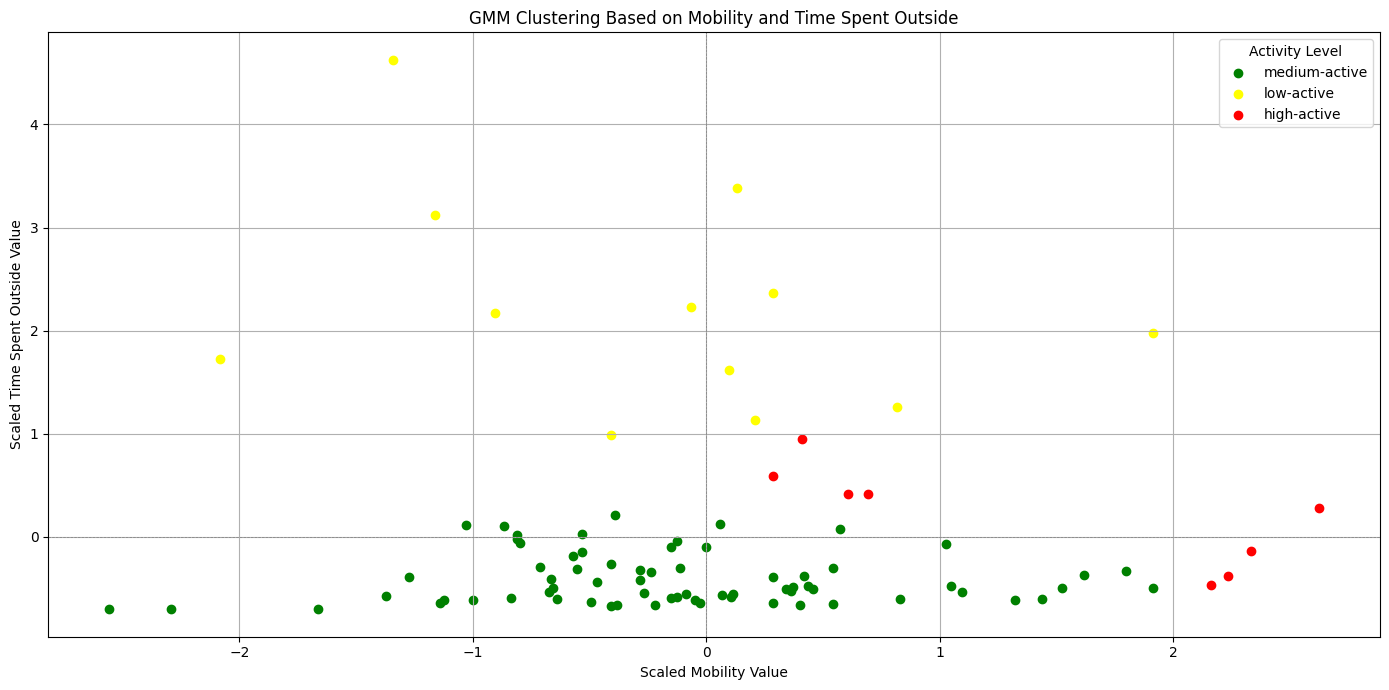

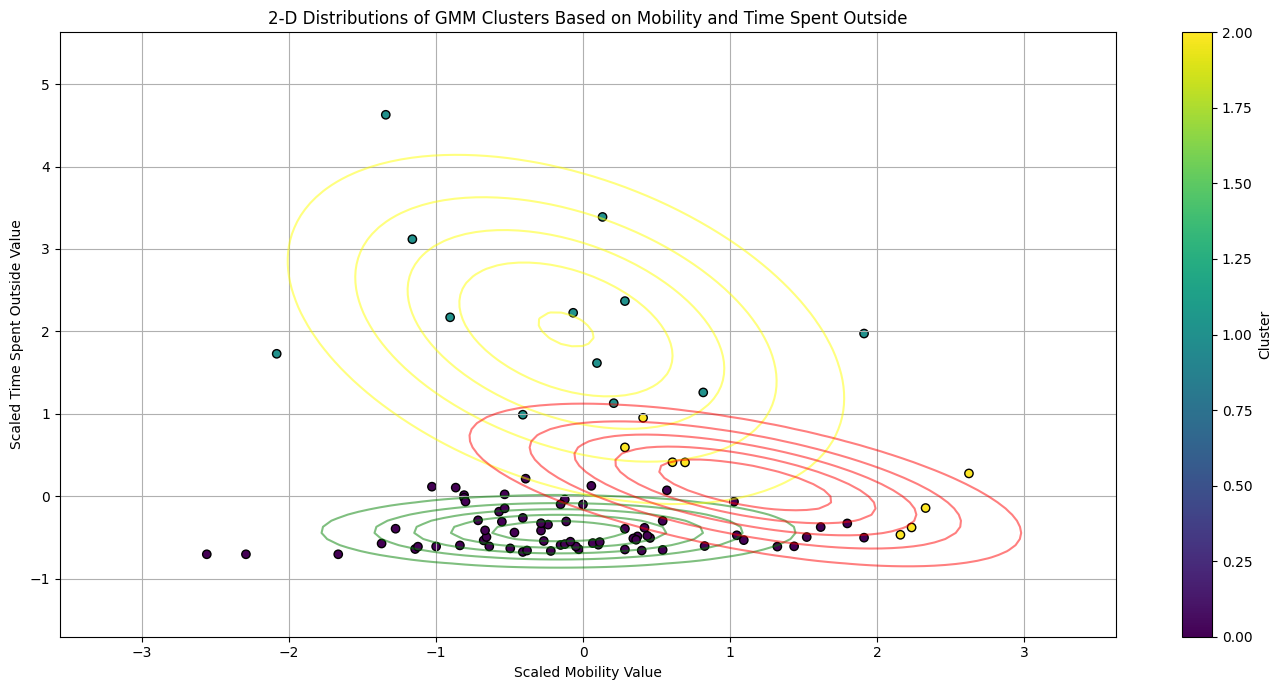

          date  mobility  time_spent_outside activity_level
0   2019-04-01      28.0            0.000000  medium-active
1   2019-04-03      94.0            0.000000  medium-active
2   2019-04-04     308.0            5.400000  medium-active
3   2019-04-05     384.0            4.266667  medium-active
4   2019-04-06     305.0            4.783333  medium-active
..         ...       ...                 ...            ...
84  2019-06-26     135.0            7.716667  medium-active
85  2019-06-27     185.0           15.916667  medium-active
86  2019-06-28     194.0           10.250000  medium-active
87  2019-06-29     128.0          132.733333     low-active
88  2019-06-30     151.0            2.300000  medium-active

[89 rows x 4 columns]


In [18]:
from scipy.stats import multivariate_normal

# Normalize the mobility and time spent outside data
scaler = StandardScaler()
mobility_scaled = scaler.fit_transform(mobility_df[['mobility', 'time_spent_outside']])

# Apply GMM clustering
gmm = GaussianMixture(n_components=3, random_state=0)
mobility_df['cluster'] = gmm.fit_predict(mobility_scaled)

# Map cluster numbers to activity labels
activity_labels = ['medium-active', 'low-active', 'high-active']  # Adjusted so the lowest value is medium-active
mobility_df['activity_level'] = mobility_df['cluster'].map(lambda x: activity_labels[x])

# Adding activity_type column for clarity
mobility_df['activity_type'] = mobility_df['activity_level']

# Plotting clusters in a 2D feature space
plt.figure(figsize=(14, 7))
colors = ['green', 'yellow', 'red']  # Define colors for each activity level

# Create a scatter plot for the scaled mobility and time spent outside values
for i, label in enumerate(activity_labels):
    plt.scatter(mobility_scaled[mobility_df['activity_level'] == label, 0],  # Scaled mobility values
                mobility_scaled[mobility_df['activity_level'] == label, 1],  # Scaled time spent outside values
                color=colors[i], label=label)

# Customize the plot
plt.title('GMM Clustering Based on Mobility and Time Spent Outside')
plt.xlabel('Scaled Mobility Value')
plt.ylabel('Scaled Time Spent Outside Value')
plt.axhline(0, color='grey', lw=0.5, linestyle='--')
plt.axvline(0, color='grey', lw=0.5, linestyle='--')
plt.legend(title='Activity Level')
plt.grid()
plt.tight_layout()

# Show the plot
plt.show()

# Create a grid for the contour plot
x = np.linspace(mobility_scaled[:, 0].min() - 1, mobility_scaled[:, 0].max() + 1, 100)
y = np.linspace(mobility_scaled[:, 1].min() - 1, mobility_scaled[:, 1].max() + 1, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))  # Create a 2D mesh for plotting

# Calculate the probability density for each cluster
Z = np.zeros(pos.shape[:2] + (gmm.n_components,))
for i in range(gmm.n_components):
    Z[:, :, i] = gmm.weights_[i] * multivariate_normal.pdf(pos, mean=gmm.means_[i], cov=gmm.covariances_[i])

# Sum the densities to get the total density
total_density = Z.sum(axis=2)

# Plot the contours for each cluster
plt.figure(figsize=(14, 7))
for i in range(gmm.n_components):
    plt.contour(X, Y, Z[:, :, i], levels=5, colors=colors[i], alpha=0.5)

# Scatter plot of the data points colored by cluster
plt.scatter(mobility_scaled[:, 0], mobility_scaled[:, 1], c=mobility_df['cluster'], cmap='viridis', marker='o', edgecolor='k')

# Customize the plot
plt.title('2-D Distributions of GMM Clusters Based on Mobility and Time Spent Outside')
plt.xlabel('Scaled Mobility Value')
plt.ylabel('Scaled Time Spent Outside Value')
plt.grid()
plt.colorbar(label='Cluster')
plt.tight_layout()

# Show the plot
plt.show()

# Display the mobility_df with clusters and activity levels
print(mobility_df[['date', 'mobility', 'time_spent_outside', 'activity_level']])

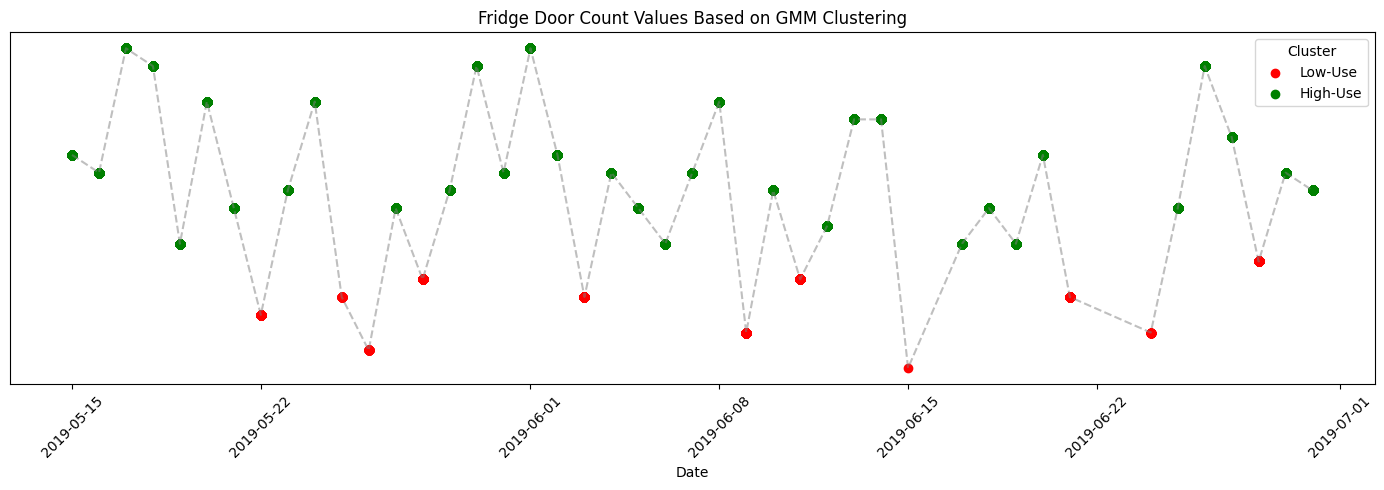

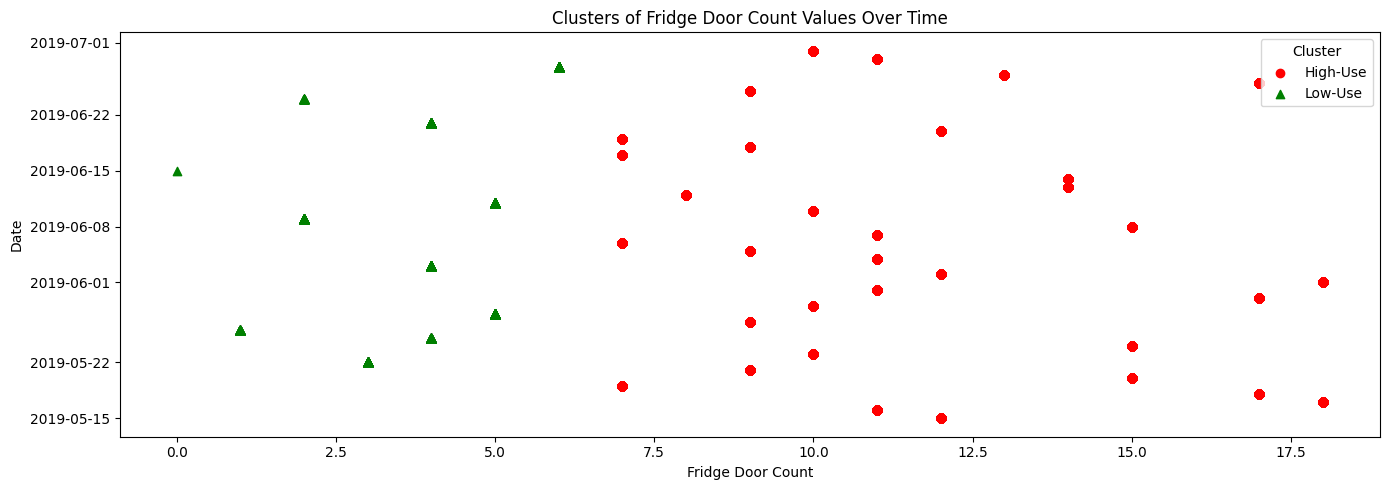

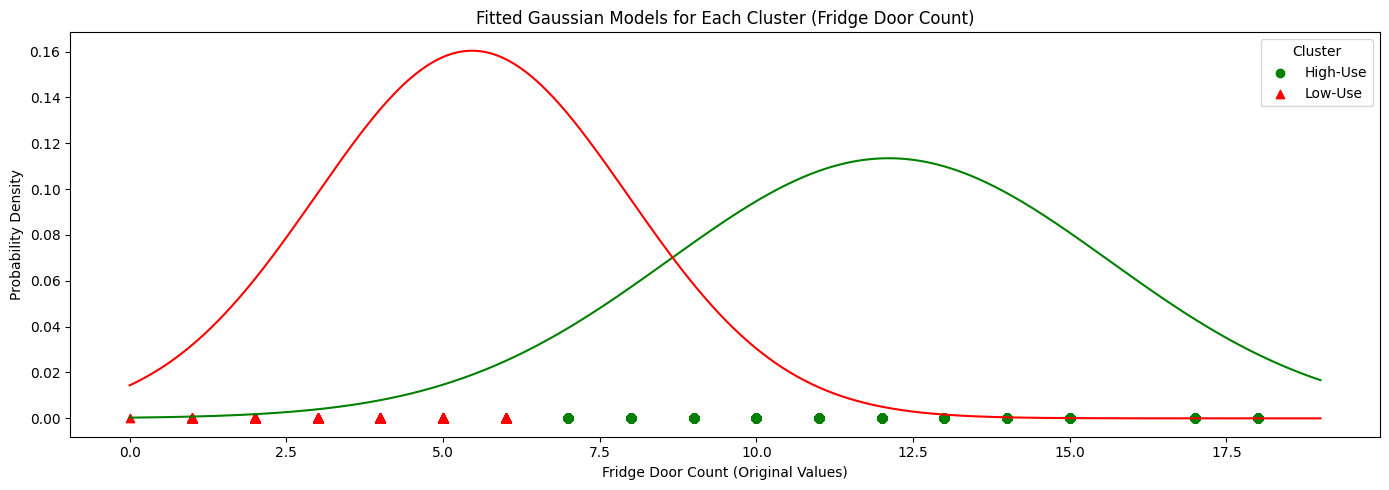

In [44]:
# Prepare data for clustering
X = id_activity_df[['fridge_door_count']].values

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Predict clusters
id_activity_df['cluster'] = gmm.predict(X)

# Assign cluster names
cluster_names = {1: 'High-Use', 0: 'Low-Use'}
id_activity_df['cluster_name'] = id_activity_df['cluster'].map(cluster_names)



# Assign cluster names and colors
id_activity_df['cluster_name'] = np.where(id_activity_df['cluster'] == 0, 'High-Use', 'Low-Use')
colors = ['red', 'green']  # Define colors for the two clusters

# Plotting clusters on a 1-D axis with fridge door count values
plt.figure(figsize=(14, 5))

# Create a scatter plot for fridge door count values
for i, label in enumerate(['Low-Use', 'High-Use']):
    plt.scatter(id_activity_df['date'][id_activity_df['cluster_name'] == label],
                id_activity_df['fridge_door_count'][id_activity_df['cluster_name'] == label],  # Fridge door counts
                color=colors[i], label=label)

# Adding dashed lines to connect the points
plt.plot(id_activity_df['date'], id_activity_df['fridge_door_count'], linestyle='--', color='gray', alpha=0.5)

# Customize the plot for fridge door count values
plt.yticks([])
plt.title('Fridge Door Count Values Based on GMM Clustering')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()



plt.figure(figsize=(14, 5))

# Create a scatter plot with fridge door count on the x-axis
for i, label in enumerate(cluster_names.values()):
    plt.scatter(id_activity_df['fridge_door_count'][id_activity_df['cluster_name'] == label],
                id_activity_df['date'][id_activity_df['cluster_name'] == label],
                color=colors[i], label=label, marker=markers[i])

plt.xlabel('Fridge Door Count')
plt.ylabel('Date')
plt.title('Clusters of Fridge Door Count Values Over Time')
plt.legend(title='Cluster')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()



# Plot the fitted Gaussian models for each cluster
plt.figure(figsize=(14, 5))

# Colors and markers for clusters
colors = ['green', 'red']
markers = ['o', '^']  # Different markers for better differentiation

# Plot the data samples with different colors based on clusters
for i, label in enumerate(cluster_names.values()):
    plt.scatter(id_activity_df['fridge_door_count'][id_activity_df['cluster_name'] == label],
                np.zeros(sum(id_activity_df['cluster_name'] == label)),  # y values are 0 for scatter plot
                color=colors[i], label=label, marker=markers[i])

# Create x values for the Gaussian curve based on original fridge door counts
x = np.linspace(0, max(id_activity_df['fridge_door_count']) + 1, 1000)

# Plot the fitted Gaussian models for each cluster based on the GMM
for i in range(gmm.n_components):
    mean = gmm.means_[i][0]  # Get the mean for the cluster
    covar = gmm.covariances_[i]  # Get the covariance for the cluster
    std = np.sqrt(covar[0][0])  # Calculate standard deviation
    y = np.exp(-0.5 * ((x - mean) ** 2) / (std ** 2)) / (std * np.sqrt(2 * np.pi))  # Density function
    plt.plot(x, y, color=colors[i])

plt.xlabel('Fridge Door Count (Original Values)')
plt.ylabel('Probability Density')
plt.title('Fitted Gaussian Models for Each Cluster (Fridge Door Count)')
plt.legend(title='Cluster')
plt.grid(False)
plt.tight_layout()

# Show the plot
plt.show()

# **Dynamic Analysis**

**Z-score Analysis based on only previous days**

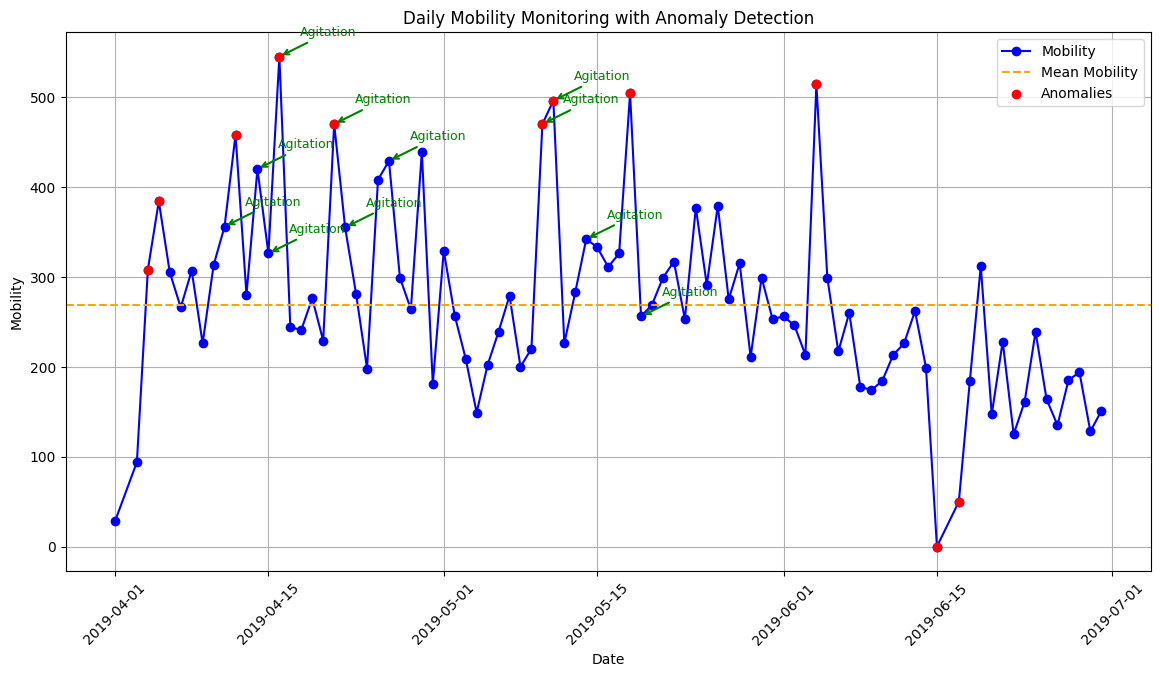

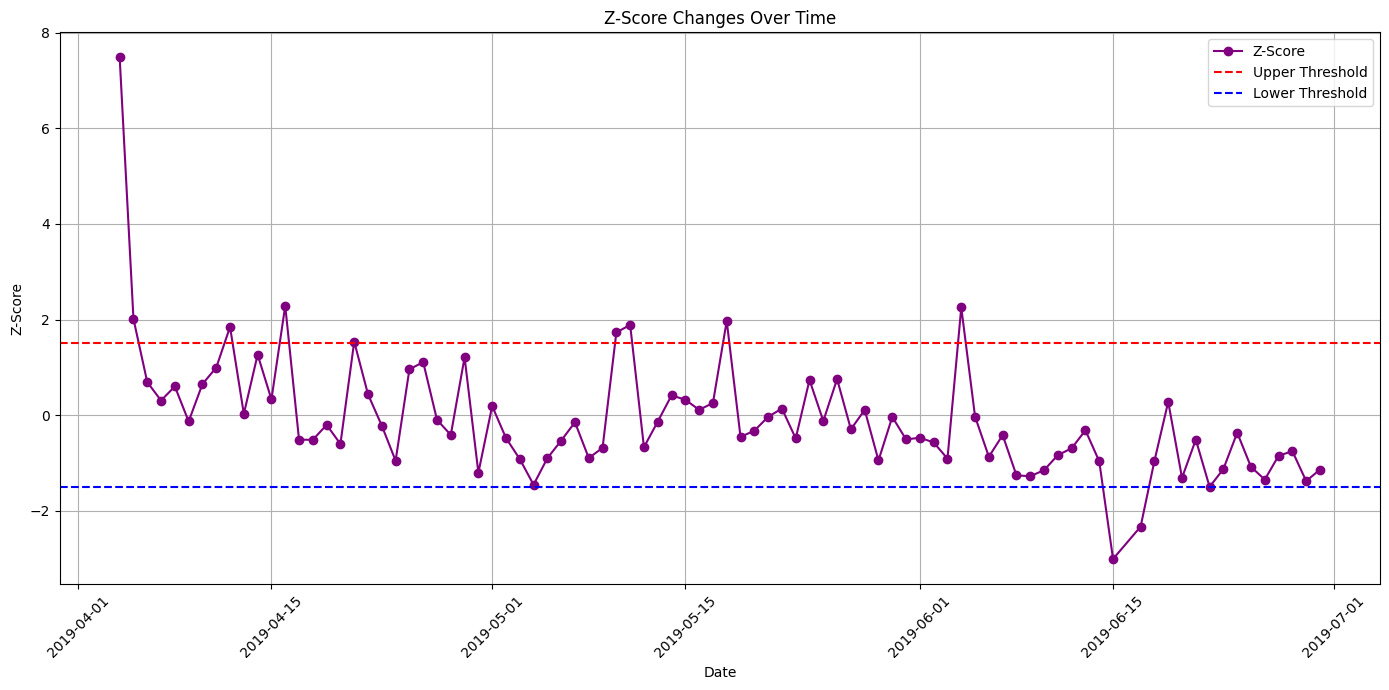

          date  mobility day_type patient_id   z_score  anomaly
0   2019-04-01      28.0   normal      16f4b       NaN    False
1   2019-04-03      94.0   normal      16f4b       NaN    False
2   2019-04-04     308.0   normal      16f4b  7.484848     True
3   2019-04-05     384.0   normal      16f4b  2.013714     True
4   2019-04-06     305.0   normal      16f4b  0.691056    False
..         ...       ...      ...        ...       ...      ...
84  2019-06-26     135.0   normal      16f4b -1.346823    False
85  2019-06-27     185.0   normal      16f4b -0.848061    False
86  2019-06-28     194.0   normal      16f4b -0.753652    False
87  2019-06-29     128.0   normal      16f4b -1.378845    False
88  2019-06-30     151.0   normal      16f4b -1.137275    False

[89 rows x 6 columns]


In [ ]:
# Initialize columns for z_score and anomaly detection
mobility_df['z_score'] = np.nan
mobility_df['anomaly'] = False

# Loop through the DataFrame to compute z_scores based on previous data only
for i in range(1, len(mobility_df)):
    # Calculate mean and std for mobility data up to the current day (excluding today)
    previous_mobility = mobility_df['mobility'][:i]

    # Calculate z_score for the current day
    if len(previous_mobility) > 1:
        mean = previous_mobility.mean()
        std = previous_mobility.std(ddof=0)  # Population standard deviation
        current_mobility = mobility_df['mobility'].iloc[i]

        # Calculate z_score
        z_score = (current_mobility - mean) / std if std > 0 else 0

        # Store in DataFrame
        mobility_df.at[i, 'z_score'] = z_score

        # Define the threshold for anomaly detection
        threshold = 1.5  # Adjust as needed
        # Update anomaly column based on z_score
        mobility_df.at[i, 'anomaly'] = abs(z_score) > threshold

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['mobility'], marker='o', label='Mobility', color='blue')
plt.axhline(y=mobility_df['mobility'].mean(), color='orange', linestyle='--', label='Mean Mobility')

# Plot anomalies if they exist
if mobility_df['anomaly'].any():
    plt.scatter(mobility_df['date'][mobility_df['anomaly']],
                mobility_df['mobility'][mobility_df['anomaly']],
                color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Daily Mobility Monitoring with Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Annotate agitation days if needed
for date in agitation_days:
    mobility_value = mobility_df[mobility_df['date'] == date]['mobility'].values[0]  # Get the mobility value for the agitation date
    plt.annotate('Agitation',
                 xy=(date, mobility_value),
                 xytext=(15, 15),  # Offset the text position
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9,
                 color='green')



# Plotting the z-score changes
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['z_score'], marker='o', label='Z-Score', color='purple')
plt.axhline(y=1.5, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(y=-1.5, color='blue', linestyle='--', label='Lower Threshold')

# Adding labels and title for z-score plot
plt.title('Z-Score Changes Over Time')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid()



plt.tight_layout()

# Show the plot
plt.show()

# Display the mobility_df with Z-scores and anomalies
print(mobility_df)

**Modified Z-score**

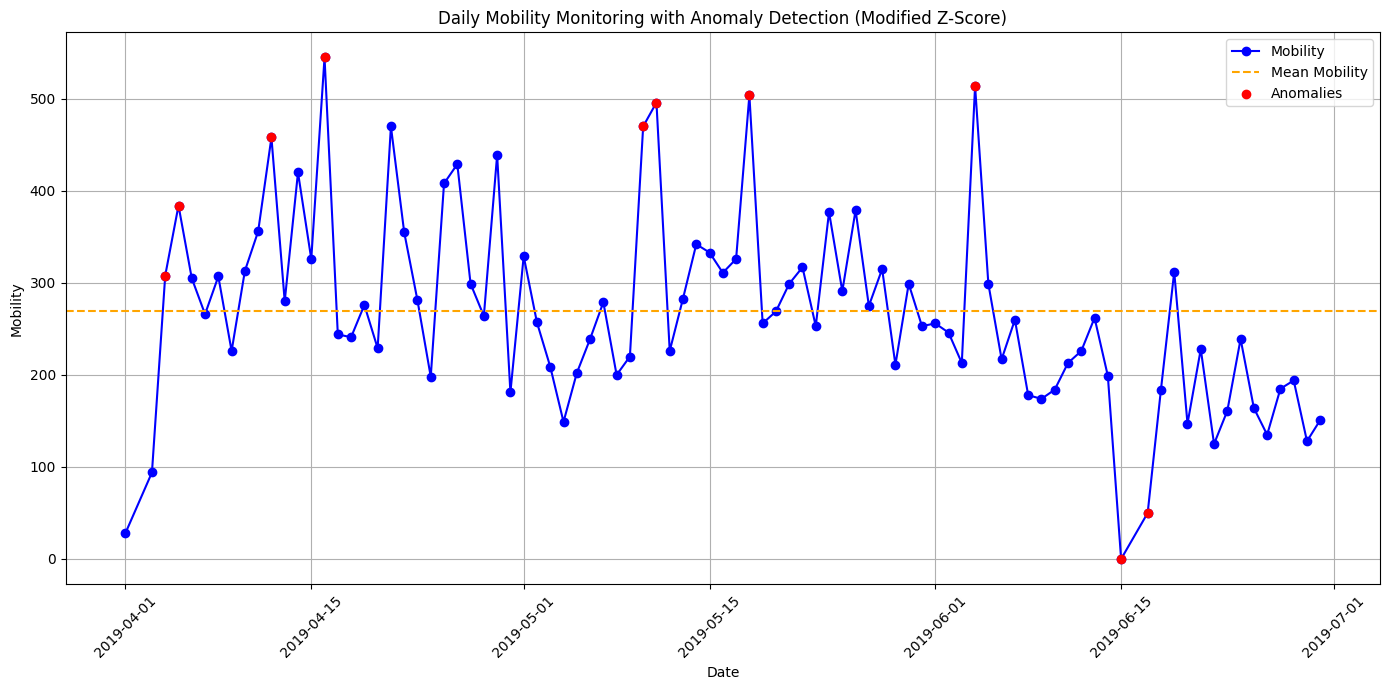

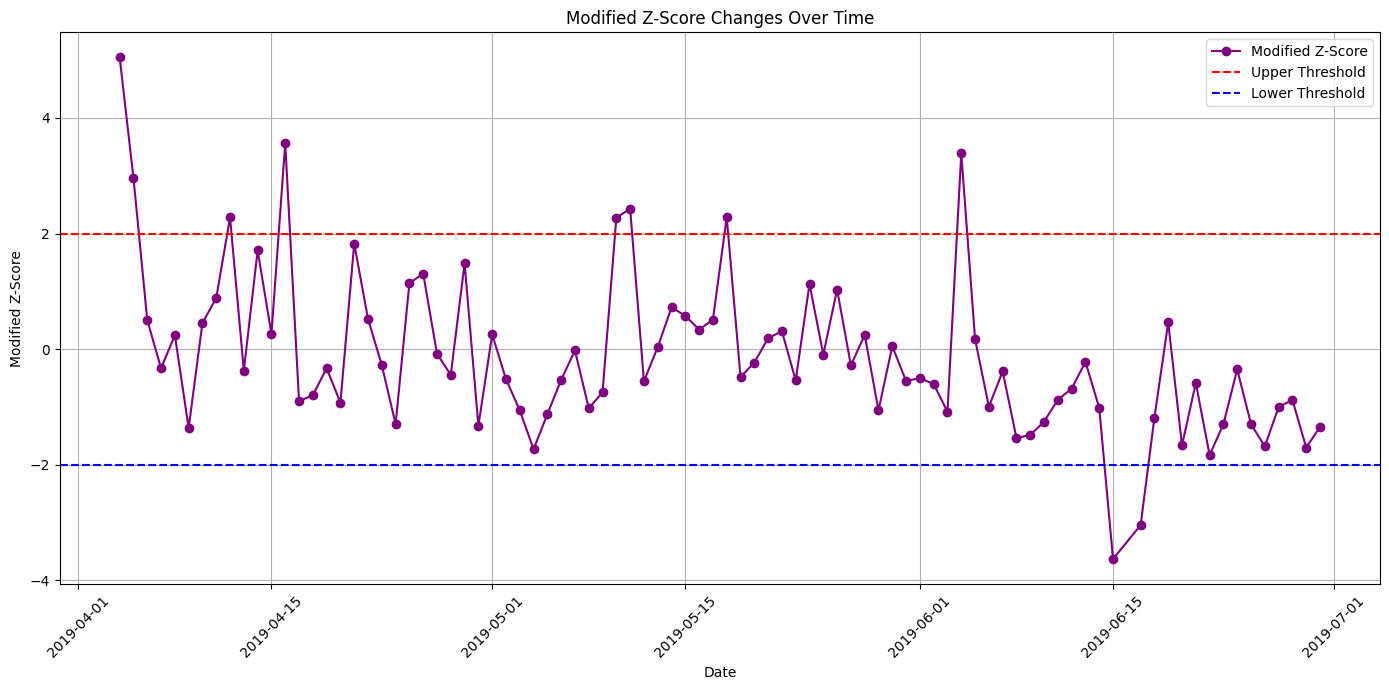

          date  mobility day_type patient_id   z_score  anomaly  \
0   2019-04-01      28.0   normal      16f4b       NaN    False   
1   2019-04-03      94.0   normal      16f4b       NaN    False   
2   2019-04-04     308.0   normal      16f4b  7.484848     True   
3   2019-04-05     384.0   normal      16f4b  2.013714     True   
4   2019-04-06     305.0   normal      16f4b  0.691056    False   
..         ...       ...      ...        ...       ...      ...   
84  2019-06-26     135.0   normal      16f4b -1.346823    False   
85  2019-06-27     185.0   normal      16f4b -0.848061    False   
86  2019-06-28     194.0   normal      16f4b -0.753652    False   
87  2019-06-29     128.0   normal      16f4b -1.378845    False   
88  2019-06-30     151.0   normal      16f4b -1.137275    False   

    modified_z_score  
0                NaN  
1                NaN  
2           5.048530  
3           2.963712  
4           0.501057  
..               ...  
84         -1.686250  
85         

In [ ]:
# Initialize columns for modified z_score and anomaly detection
mobility_df['modified_z_score'] = np.nan
mobility_df['anomaly'] = False

# Loop through the DataFrame to compute modified z_scores based on previous data only
for i in range(1, len(mobility_df)):
    # Mobility data up to the current day (excluding today)
    previous_mobility = mobility_df['mobility'][:i]

    # Calculate modified z_score for the current day
    if len(previous_mobility) > 1:
        median = previous_mobility.median()
        mad = np.median(np.abs(previous_mobility - median))  # Calculate MAD

        current_mobility = mobility_df['mobility'].iloc[i]

        # Calculate modified z_score
        if mad > 0:  # Avoid division by zero
            modified_z_score = 0.6745 * (current_mobility - median) / mad
        else:
            modified_z_score = 0  # Assign 0 if MAD is 0

        # Store in DataFrame
        mobility_df.at[i, 'modified_z_score'] = modified_z_score

        # Define the threshold for anomaly detection
        threshold = 2  # Commonly used threshold for modified z-score detection
        # Update anomaly column based on modified_z_score
        mobility_df.at[i, 'anomaly'] = abs(modified_z_score) > threshold

# Plotting the results for mobility and anomalies
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['mobility'], marker='o', label='Mobility', color='blue')
plt.axhline(y=mobility_df['mobility'].mean(), color='orange', linestyle='--', label='Mean Mobility')

# Plot anomalies if they exist
if mobility_df['anomaly'].any():
    plt.scatter(mobility_df['date'][mobility_df['anomaly']],
                mobility_df['mobility'][mobility_df['anomaly']],
                color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Daily Mobility Monitoring with Anomaly Detection (Modified Z-Score)')
plt.xlabel('Date')
plt.ylabel('Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()



plt.tight_layout()
plt.show()  # Show the first plot

# Plotting the modified z-score changes
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['modified_z_score'], marker='o', label='Modified Z-Score', color='purple')
plt.axhline(y=threshold, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(y=-1*threshold, color='blue', linestyle='--', label='Lower Threshold')

# Adding labels and title for modified z-score plot
plt.title('Modified Z-Score Changes Over Time')
plt.xlabel('Date')
plt.ylabel('Modified Z-Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()  # Show the modified z-score plot

# Display the mobility_df with modified Z-scores and anomalies
print(mobility_df)

**Control Chart**

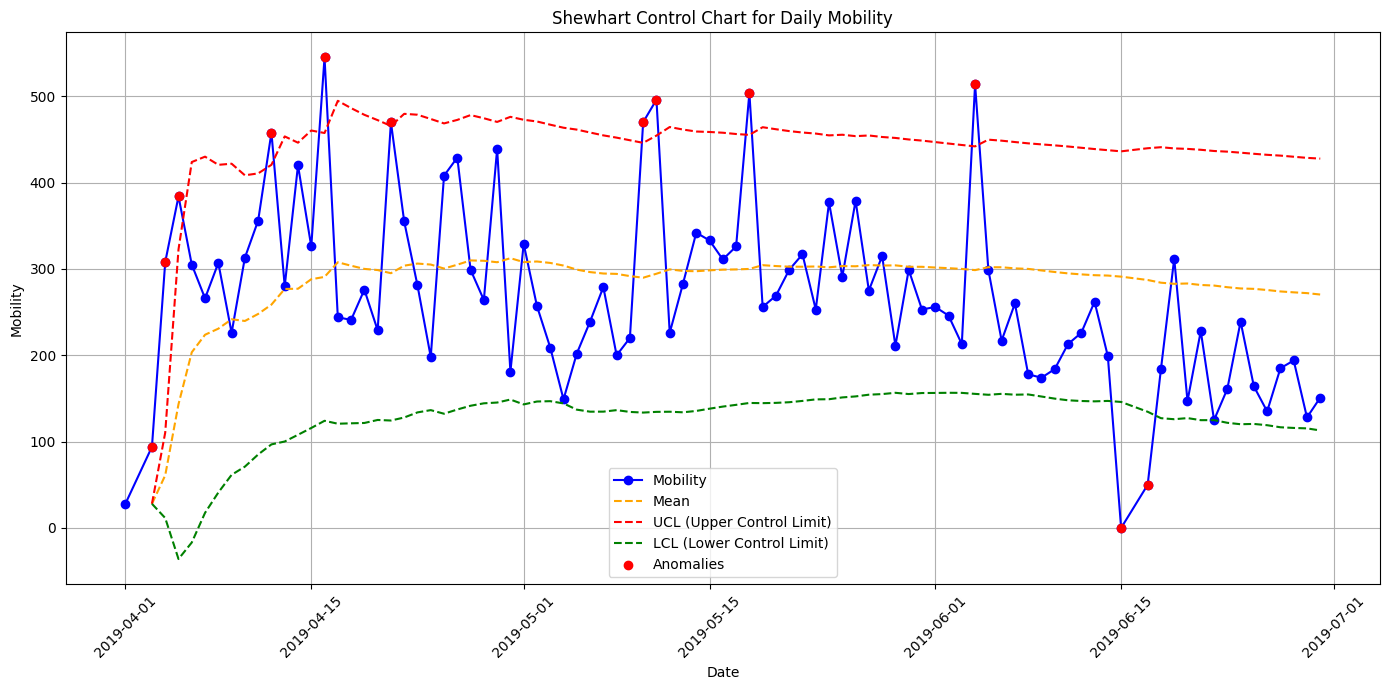

          date  mobility day_type patient_id   z_score  anomaly  \
0   2019-04-01      28.0   normal      16f4b       NaN    False   
1   2019-04-03      94.0   normal      16f4b       NaN     True   
2   2019-04-04     308.0   normal      16f4b  7.484848     True   
3   2019-04-05     384.0   normal      16f4b  2.013714     True   
4   2019-04-06     305.0   normal      16f4b  0.691056    False   
..         ...       ...      ...        ...       ...      ...   
84  2019-06-26     135.0   normal      16f4b -1.346823    False   
85  2019-06-27     185.0   normal      16f4b -0.848061    False   
86  2019-06-28     194.0   normal      16f4b -0.753652    False   
87  2019-06-29     128.0   normal      16f4b -1.378845    False   
88  2019-06-30     151.0   normal      16f4b -1.137275    False   

    modified_z_score        mean         UCL         LCL  
0                NaN         NaN         NaN         NaN  
1                NaN   28.000000   28.000000   28.000000  
2           5.0485

In [ ]:
# Initialize columns for mean and control limits
mobility_df['mean'] = np.nan
mobility_df['UCL'] = np.nan  # Upper Control Limit
mobility_df['LCL'] = np.nan  # Lower Control Limit
mobility_df['anomaly'] = False

# Loop through the DataFrame to compute mean and control limits based on previous data only
for i in range(1, len(mobility_df)):
    # Mobility data up to the current day (excluding today)
    previous_mobility = mobility_df['mobility'][:i]

    # Calculate mean and standard deviation for the previous days
    mean = previous_mobility.mean()
    std_dev = previous_mobility.std(ddof=0)  # Population standard deviation

    # Calculate control limits
    threshold = 1.5
    UCL = mean + threshold * std_dev  # Upper Control Limit
    LCL = mean - threshold * std_dev  # Lower Control Limit

    # Store in DataFrame
    mobility_df.at[i, 'mean'] = mean
    mobility_df.at[i, 'UCL'] = UCL
    mobility_df.at[i, 'LCL'] = LCL

    # Check for anomalies
    current_mobility = mobility_df['mobility'].iloc[i]
    if current_mobility > UCL or current_mobility < LCL:
        mobility_df.at[i, 'anomaly'] = True  # Mark as an anomaly

# Plotting the results for mobility and control limits
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['mobility'], marker='o', label='Mobility', color='blue')
plt.plot(mobility_df['date'], mobility_df['mean'], linestyle='--', color='orange', label='Mean')
plt.plot(mobility_df['date'], mobility_df['UCL'], linestyle='--', color='red', label='UCL (Upper Control Limit)')
plt.plot(mobility_df['date'], mobility_df['LCL'], linestyle='--', color='green', label='LCL (Lower Control Limit)')

# Highlight anomalies
if mobility_df['anomaly'].any():
    plt.scatter(mobility_df['date'][mobility_df['anomaly']],
                mobility_df['mobility'][mobility_df['anomaly']],
                color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Shewhart Control Chart for Daily Mobility')
plt.xlabel('Date')
plt.ylabel('Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()  # Show the control chart

# Display the mobility_df with mean, UCL, LCL, and anomalies
print(mobility_df)

**Autoencoder**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

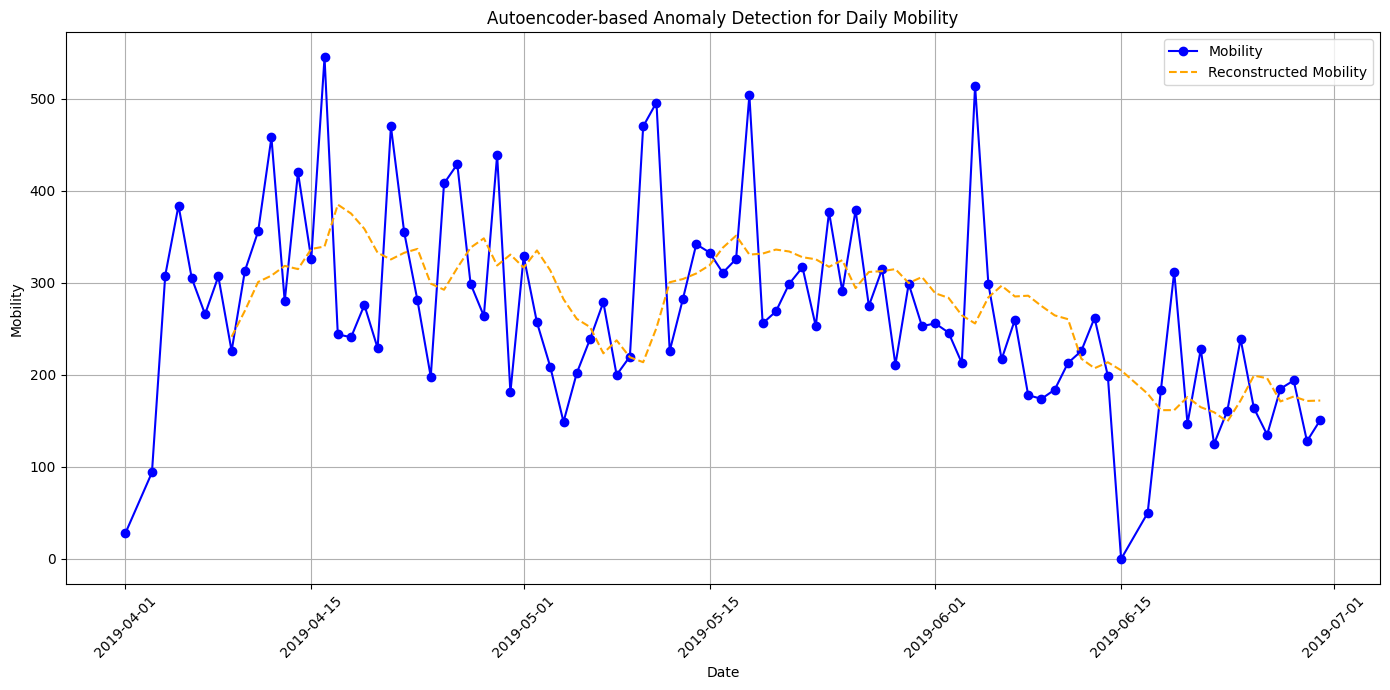

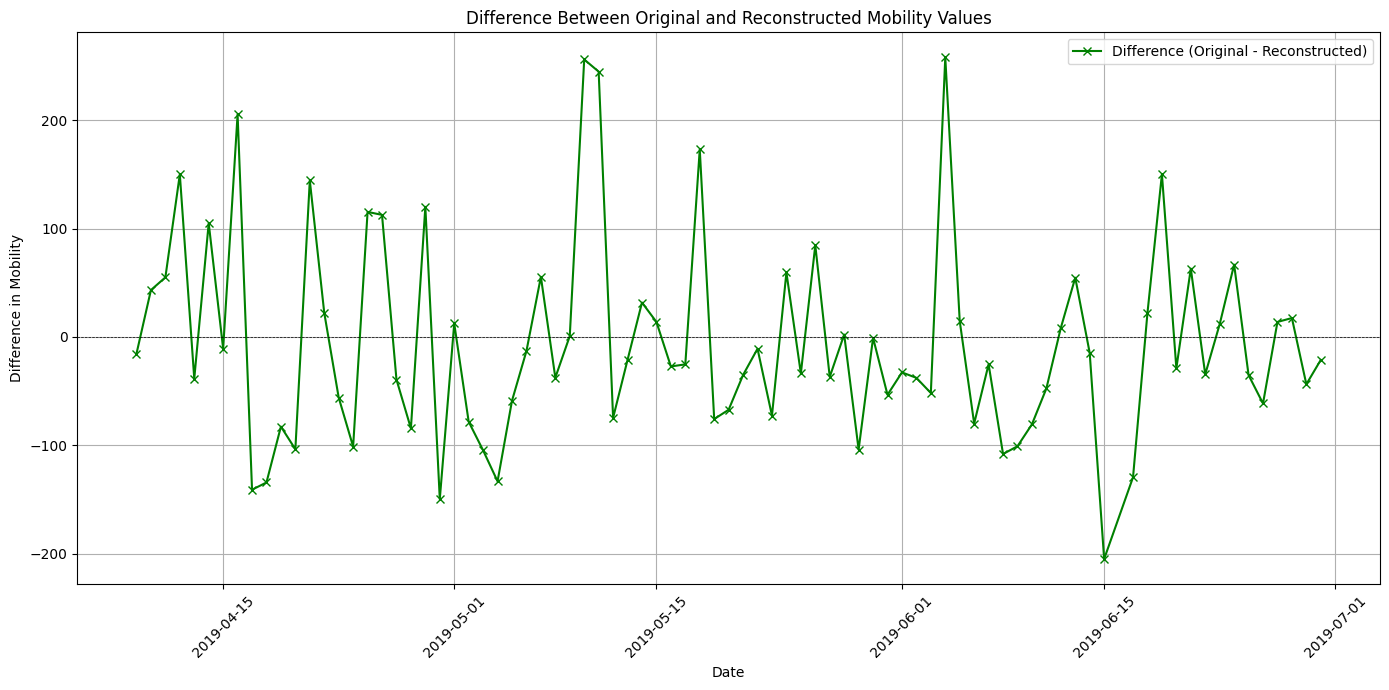

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense

# Normalize the mobility data
scaler = MinMaxScaler()
mobility_scaled = scaler.fit_transform(mobility_df[['mobility']])

# Prepare the data for the autoencoder training with a fixed window size
window_size = 7
X_train = []
y_train = []

# Collect previous days for training using a sliding window approach
for i in range(window_size, len(mobility_scaled)):
    X_train.append(mobility_scaled[i-window_size:i].flatten())  # Use the last 'window_size' entries
    y_train.append(mobility_scaled[i][0])  # Use the current value as the output

# Convert to numpy array
X_train = np.array(X_train)
y_train = np.array(y_train)

# Create the autoencoder model (input shape matches the window_size)
model = Sequential()
model.add(Dense(10, input_shape=(X_train.shape[1],), activation='relu'))  # Encoder
model.add(Dense(1, activation='linear'))  # Decoder
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the autoencoder
model.fit(X_train, X_train, epochs=100, batch_size=1, verbose=0)

# Calculate reconstruction error and determine anomalies
mobility_df['reconstructed'] = np.nan
mobility_df['anomaly'] = False

for i in range(window_size, len(mobility_df)):
    previous_data = mobility_scaled[i-window_size:i].flatten()  # Use only the last 'window_size' entries
    if len(previous_data) > 0:
        # Predict reconstruction for the flattened array
        reconstructed = model.predict(previous_data.reshape(1, -1))
        reconstruction_error = np.mean((previous_data - reconstructed.flatten()) ** 2)
        mobility_df.at[i, 'reconstructed'] = scaler.inverse_transform(reconstructed.reshape(-1, 1)).flatten()[0]

        # Set a threshold for anomalies (e.g., 3 times the mean error from training set)
        threshold = 3 * np.mean(np.mean((X_train - model.predict(X_train)) ** 2))

        if reconstruction_error > threshold:
            mobility_df.at[i, 'anomaly'] = True  # Mark as an anomaly

# Plotting the results for mobility and anomalies
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['mobility'], marker='o', label='Mobility', color='blue')
plt.plot(mobility_df['date'], mobility_df['reconstructed'], linestyle='--', color='orange', label='Reconstructed Mobility')

# Highlight anomalies
if mobility_df['anomaly'].any():
    plt.scatter(mobility_df['date'][mobility_df['anomaly']],
                mobility_df['mobility'][mobility_df['anomaly']],
                color='red', label='Anomalies', zorder=5)

# Adding labels and title
plt.title('Autoencoder-based Anomaly Detection for Daily Mobility')
plt.xlabel('Date')
plt.ylabel('Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()  # Show the plot

# Calculate the difference between original and reconstructed values
mobility_df['difference'] = mobility_df['mobility'] - mobility_df['reconstructed']

# Plotting the difference
plt.figure(figsize=(14, 7))
plt.plot(mobility_df['date'], mobility_df['difference'], marker='x', color='green', label='Difference (Original - Reconstructed)')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

# Adding labels and title for the difference
plt.title('Difference Between Original and Reconstructed Mobility Values')
plt.xlabel('Date')
plt.ylabel('Difference in Mobility')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()  # Show the difference plot
